# Notebook 01 — AAA US Gas Price: Daily, Weekly & Monthly Forecasting for Kalshi

**Markets:** Kalshi `KXAAAGASD` (daily), `KXAAAGASW` (weekly), `KXAAAGASM` (monthly) — also tradable on Robinhood
**Target (X):** AAA national average price of regular gasoline on the contract's date

---

### Project Overview

This notebook replicates the pipeline of *Individual Project — Time Series Analysis & Forecasting (Logitech)*,
applied to a prediction market instead of product sales.

| Stage | Description |
|-------|-------------|
| **Part 1** | Data loading & cleaning — Kalshi settlements, EIA bridge, exogenous drivers |
| **Part 2** | Exploratory Data Analysis — trends, seasonality, change distributions, **driver discovery** |
| **Part 3** | Time series diagnostics — stationarity tests, decomposition, ACF/PACF |
| **Part 4** | Forecasting — SARIMAX, Log-SARIMAX, ETS, 7 Nixtla models, ML (GB + RF), baselines, ensemble |
| **Part 5** | Critique & next steps |
| **Part 6** | **Kalshi translation** — forecast distribution → P(bracket) → edge vs market price after fees |

### How the Kalshi market connects to X

Every contract is a yes/no question on one number:

> *"Will average regular gas prices for United States be **strictly greater than $K** on **date D** according to AAA?"*

So one event (a date) is a **ladder of strikes** K₁ < K₂ < … and each strike trades between $0 and $1.
The market price of the "Yes" contract at strike K *is* the crowd's probability that X_D > K.

1. Forecast X_D (point forecast from the best model in the tournament).
2. Turn it into a distribution using the model's own cross-validation errors: X_D ~ N(forecast + bias, σ_CV).
3. P_model(X_D > K) = 1 − Φ((K − μ) / σ) for every strike on the ladder.
4. Edge = P_model − price paid − Kalshi fee. Only bet when edge is clearly positive.

### How we know which variables relate to X (Part 2.6)

Correlating price *levels* is misleading — any two trending prices look correlated. We use four filters:
1. **Economic prior:** candidates come from the supply chain (crude → wholesale gasoline → pump), plus a placebo (10Y Treasury).
2. **Lead-lag correlation on changes:** corr(ΔX_t, Δdriver_{t−k}) for k = 0…8. A driver is useful only if it moves **before** X (k ≥ 1).
3. **Granger causality:** do past driver changes improve the prediction of X changes beyond X's own past?
4. **Out-of-sample test (final judge):** models with the driver (SARIMAX-X, GB-X, RF-X) must beat the same models without it in cross-validation (Part 4).

### Adjustments vs. the original notebook
| Original | Here | Why |
|---|---|---|
| Monthly, season 12, horizon 12 | Daily (7), weekly (52), monthly (12); horizon = **1 step** | A Kalshi contract resolves on the next date |
| 2 folds × 12-month validation | 24–28 folds × 1-step validation, pooled RMSE | Many one-step bets; long histories |
| No exogenous variables | SARIMAX-X, GB-X, RF-X with lagged drivers | The original's own "Limitations" next step |
| SARIMAX by AIC over mixed `d` | `d`, `D` fixed by automatic tests; AIC compares orders with the same differencing; CV scores the winner | AIC is not comparable across differencing orders |
| — | Exogenous drivers enter as ECM (if cointegrated) or changes, never raw levels | Avoid spurious regression |
| ML predicts levels | ML predicts the change when `d ≥ 1` | Trees cannot extrapolate trending levels |
| Seasonal Naive / Drift baselines | + **Naive (random walk)** | For prices, "tomorrow = today" is the baseline to beat |
| Point forecasts only | CV-error distribution → bracket probabilities | Kalshi sells brackets |

In [1]:
import warnings

warnings.filterwarnings("ignore")

import contextlib
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Nixtla StatsForecast — full model suite
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    AutoCES,
    AutoTheta,
    DynamicOptimizedTheta,
    OptimizedTheta,
)
from statsforecast.models import (
    AutoETS as NixtlaAutoETS,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss

# Shared, automatic stationarity decisions (src/prediction_markets_forecasting/stationarity.py)
from prediction_markets_forecasting.stationarity import decide, exog_features, exog_next

# Plotting style (same as original)
plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "figure.dpi": 100,
    }
)

AS_OF = pd.Timestamp.now().normalize()
KALSHI = "https://api.elections.kalshi.com/trade-api/v2"
FRED = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={}"
OUT = Path("../data/outputs")
OUT.mkdir(parents=True, exist_ok=True)

# One configuration per contract frequency
CFG = {
    "daily": dict(series="KXAAAGASD", freq="D", season=7, n_folds=28, min_train=60, n_lags=7),
    "weekly": dict(
        series="KXAAAGASW", freq="W-MON", season=52, n_folds=26, min_train=156, n_lags=12
    ),
    "monthly": dict(series="KXAAAGASM", freq="ME", season=12, n_folds=24, min_train=60, n_lags=12),
}
WEEKLY_START = "2015-01-01"  # ~10 years of weekly history (post-shale regime)
MONTHLY_START = "2007-01-01"  # all exogenous drivers available from here
print(f"As of: {AS_OF:%Y-%m-%d}")

As of: 2026-09-23


---
# Part 1: Data Loading & Cleaning

| Issue | Description | Solution |
|-------|-------------|----------|
| Resolution source | Kalshi resolves on AAA, which publishes no free history | Use Kalshi's own settled markets: `expiration_value` = exact AAA value |
| Mixed series in history | Historical endpoint returns legacy tickers (`AAAGASD-23OCT03-US`) and even monthly events inside the weekly series | Parse the date with a regex; keep only events whose prefix matches the series |
| Non-numeric settlements | Some settled markets carry `expiration_value = "No"` | Coerce to numeric, drop |
| Duplicates | One event (date) has many strike markets with the same value | Keep one value per event |
| Short AAA history | Kalshi settlements start in 2023 (weekly/monthly) and 2026 (daily, contiguous) | Bridge weekly/monthly to EIA retail gas (FRED `GASREGW`, since 1990) with a bias correction |
| Daily gaps | Missing days in the daily series | Keep the last contiguous block; forward-fill gaps ≤ 3 days |
| Look-ahead in drivers | A driver's value on date t may not be known when AAA publishes | Use the driver's value from the **previous calendar day** |

## 1.1 Kalshi settlements (the target, straight from the resolution source)

In [2]:
def kalshi_get(path, key="markets", **params):
    # Page through a Kalshi endpoint with cursor pagination and back off on HTTP 429.
    out, cursor = [], None
    while True:
        q = {"limit": 1000, **params}
        if cursor:
            q["cursor"] = cursor
        for attempt in range(6):
            r = requests.get(KALSHI + path, params=q, timeout=30)
            if r.status_code != 429:
                break
            time.sleep(2**attempt)
        r.raise_for_status()
        d = r.json()
        out += d.get(key, [])
        cursor = d.get("cursor")
        if not cursor or not d.get(key):
            return out
        time.sleep(0.25)


def kalshi_settlements(series_ticker):
    # Exact AAA values at which each settled event resolved (historical + recent).
    raw = kalshi_get("/historical/markets", series_ticker=series_ticker) + kalshi_get(
        "/markets", series_ticker=series_ticker, status="settled"
    )
    df = pd.DataFrame(
        [{"event": m["event_ticker"], "value": m.get("expiration_value")} for m in raw]
    )
    n_events = df["event"].nunique()
    # The historical endpoint also returns legacy tickers (e.g. 'AAAGASD-23OCT03-US') and, for the weekly
    # series, some legacy MONTHLY events ('AAAGASM-23NOV30-US'). Keep only this series' own events.
    parts = df["event"].str.extract(r"^(?P<prefix>[A-Z]+)-(?P<date>\d{2}[A-Z]{3}\d{2})")
    core = series_ticker.removeprefix("KX")
    own = parts["prefix"].isin([series_ticker, core])
    n_foreign = int(df.loc[~own, "event"].nunique())
    df = df[own].assign(date_str=parts.loc[own, "date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    n_bad = int(df.groupby("event")["value"].apply(lambda v: v.isna().all()).sum())
    df = df.dropna(subset=["value"]).drop_duplicates("event")
    df["date"] = pd.to_datetime(df["date_str"], format="%y%b%d")
    s = df.sort_values("date").set_index("date")["value"]
    s = s[~s.index.duplicated()].rename(series_ticker)
    return s, {
        "series": series_ticker,
        "markets": len(raw),
        "events": n_events,
        "foreign_events_dropped": n_foreign,
        "non_numeric_events": n_bad,
        "clean_obs": len(s),
        "start": s.index.min().date(),
        "end": s.index.max().date(),
    }


aaa, reports = {}, []
for k, cfg in CFG.items():
    aaa[k], rep = kalshi_settlements(cfg["series"])
    reports.append({"frequency": k, **rep})

print("=" * 70)
print("KALSHI SETTLEMENT DATA QUALITY REPORT")
print("=" * 70)
pd.DataFrame(reports)

KALSHI SETTLEMENT DATA QUALITY REPORT


,frequency,series,markets,events,foreign_events_dropped,non_numeric_events,clean_obs,start,end
0,daily,KXAAAGASD,3440,207,0,0,207,2023-09-18,2026-09-23
1,weekly,KXAAAGASW,976,137,2,1,134,2023-10-09,2026-09-21
2,monthly,KXAAAGASM,425,33,0,0,33,2023-12-31,2026-08-31


## 1.2 Weekly target — bridging AAA to EIA

AAA weekly settlements only go back to late 2023. EIA publishes the U.S. regular retail gas price every Monday
since 1990 (FRED `GASREGW`). AAA settles `KXAAAGASW` on Mondays too, so we check how close the two are.

Overlapping Mondays: 134
AAA − EIA: mean = +1.51¢, std = 1.04¢, max |diff| = 4.20¢
Correlation of levels:         0.9997
Correlation of weekly changes: 0.9970


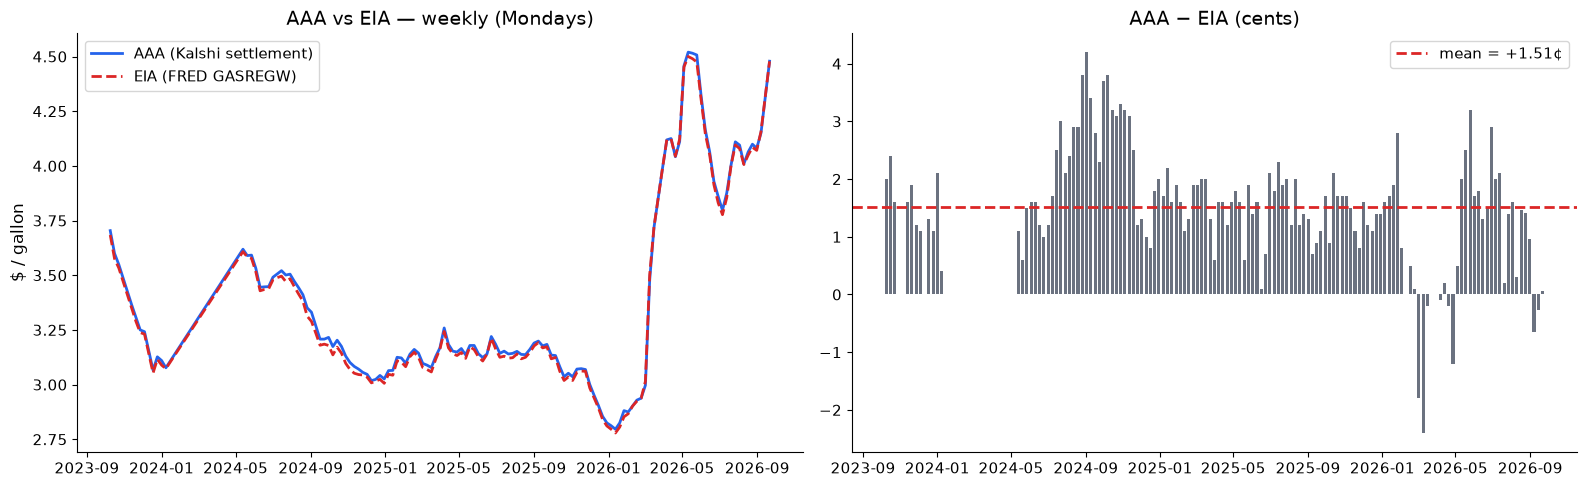

In [3]:
def fred(series_id):
    df = pd.read_csv(FRED.format(series_id), parse_dates=["observation_date"])
    s = pd.to_numeric(df[series_id], errors="coerce")
    return pd.Series(s.values, index=df["observation_date"], name=series_id).dropna()


eia_w = fred("GASREGW")
aaa_w_mon = aaa["weekly"][aaa["weekly"].index.dayofweek == 0]  # Monday settlements only

bridge = pd.concat([aaa_w_mon.rename("AAA"), eia_w.rename("EIA")], axis=1, sort=True).dropna()
bridge["diff"] = bridge["AAA"] - bridge["EIA"]
BIAS_W = bridge["diff"].mean()

print(f"Overlapping Mondays: {len(bridge)}")
print(
    f'AAA − EIA: mean = {BIAS_W*100:+.2f}¢, std = {bridge["diff"].std()*100:.2f}¢, '
    f'max |diff| = {bridge["diff"].abs().max()*100:.2f}¢'
)
print(f'Correlation of levels:         {bridge["AAA"].corr(bridge["EIA"]):.4f}')
print(f'Correlation of weekly changes: {bridge["AAA"].diff().corr(bridge["EIA"].diff()):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(bridge.index, bridge["AAA"], label="AAA (Kalshi settlement)", color="#2563eb")
axes[0].plot(
    bridge.index, bridge["EIA"], label="EIA (FRED GASREGW)", color="#dc2626", linestyle="--"
)
axes[0].set_title("AAA vs EIA — weekly (Mondays)")
axes[0].set_ylabel("$ / gallon")
axes[0].legend()
axes[1].bar(bridge.index, bridge["diff"] * 100, width=5, color="#6b7280")
axes[1].axhline(BIAS_W * 100, color="#dc2626", linestyle="--", label=f"mean = {BIAS_W*100:+.2f}¢")
axes[1].set_title("AAA − EIA (cents)")
axes[1].legend()
plt.tight_layout()
plt.show()

In [4]:
# Weekly target: EIA + bias, replaced by the real AAA settlement wherever it exists
y_w = (eia_w + BIAS_W).combine_first(aaa_w_mon).asfreq("W-MON")
src_w = pd.Series("EIA + bias", index=y_w.index)
common = aaa_w_mon.index.intersection(y_w.index)
y_w.loc[common] = aaa_w_mon.loc[common]
src_w.loc[common] = "AAA (Kalshi)"
n_missing_w = int(y_w.isna().sum())
y_w = y_w.ffill()[WEEKLY_START:].rename("weekly")
src_w = src_w[WEEKLY_START:]
print(f"Weekly target: {len(y_w)} weeks, {y_w.index.min():%Y-%m-%d} → {y_w.index.max():%Y-%m-%d}")
print(
    f'  AAA actuals: {(src_w == "AAA (Kalshi)").sum()} | EIA + bias: {(src_w == "EIA + bias").sum()} '
    f'| forward-filled gaps: {n_missing_w}'
)

Weekly target: 612 weeks, 2015-01-05 → 2026-09-21
  AAA actuals: 134 | EIA + bias: 478 | forward-filled gaps: 6


## 1.3 Monthly target — AAA on the last day of the month

`KXAAAGASM` resolves on the AAA price **on the last day of the month** (not the monthly average).
EIA is weekly, so we interpolate it daily and read it at each month-end, then apply the same bias correction.

In [5]:
eia_daily = eia_w.resample("D").interpolate("time")
eia_me = eia_daily[eia_daily.index.is_month_end]

bridge_m = pd.concat(
    [aaa["monthly"].rename("AAA"), eia_me.rename("EIA")], axis=1, sort=True
).dropna()
BIAS_M = (bridge_m["AAA"] - bridge_m["EIA"]).mean()
print(
    f'Monthly overlap: {len(bridge_m)} month-ends | AAA − EIA(interp) mean = {BIAS_M*100:+.2f}¢, '
    f'std = {(bridge_m["AAA"] - bridge_m["EIA"]).std()*100:.2f}¢'
)

y_m = (eia_me + BIAS_M).combine_first(aaa["monthly"])
y_m.loc[aaa["monthly"].index] = aaa["monthly"]
y_m = y_m.asfreq("ME").ffill()[MONTHLY_START:].rename("monthly")
src_m = pd.Series(
    np.where(y_m.index.isin(aaa["monthly"].index), "AAA (Kalshi)", "EIA interp + bias"),
    index=y_m.index,
)
print(
    f'Monthly target: {len(y_m)} months, {y_m.index.min():%Y-%m} → {y_m.index.max():%Y-%m} '
    f'| AAA actuals: {(src_m == "AAA (Kalshi)").sum()}'
)

Monthly overlap: 33 month-ends | AAA − EIA(interp) mean = +2.04¢, std = 1.28¢
Monthly target: 236 months, 2007-01 → 2026-08 | AAA actuals: 33


## 1.4 Daily target — AAA daily settlements

No long free daily history exists for AAA, so the daily model trains only on Kalshi settlements.
We keep the last contiguous block (gaps ≤ 3 days) and forward-fill the small gaps, as the original notebook did.

In [6]:
obs = aaa["daily"]
gap = obs.index.to_series().diff().dt.days
big_gaps = gap[gap > 3]
start_d = big_gaps.index.max() if len(big_gaps) else obs.index.min()
y_d = obs[start_d:].asfreq("D")
n_filled_d = int(y_d.isna().sum())
y_d = y_d.ffill().rename("daily")
print(
    f"Daily settlements total: {len(obs)} | big gaps (>3 days): {len(big_gaps)} "
    f"(largest {int(gap.max())} days)"
)
print(
    f"Daily target (last contiguous block): {len(y_d)} days, "
    f"{y_d.index.min():%Y-%m-%d} → {y_d.index.max():%Y-%m-%d} | forward-filled days: {n_filled_d}"
)

Daily settlements total: 207 | big gaps (>3 days): 4 (largest 688 days)
Daily target (last contiguous block): 182 days, 2026-03-26 → 2026-09-23 | forward-filled days: 0


## 1.5 Exogenous driver candidates

Candidates follow the supply chain from crude to the pump, plus the dollar and a **placebo** (10Y Treasury yield)
that should *not* predict gas prices. If the placebo passes our filters, the filters are too loose.

In [7]:
FRED_EXOG = {
    "DGASUSGULF": "Gulf Coast gasoline spot (FRED)",
    "DGASNYH": "NY Harbor gasoline spot (FRED)",
    "DCOILWTICO": "WTI crude spot (FRED)",
    "DCOILBRENTEU": "Brent crude spot (FRED)",
    "DHOILNYH": "NY Harbor heating oil spot (FRED)",
    "DTWEXBGS": "Trade-weighted US dollar (FRED)",
    "DGS10": "10Y Treasury yield — placebo (FRED)",
}
YF_EXOG = {"RB=F": "RBOB gasoline futures (Yahoo)", "CL=F": "WTI crude futures (Yahoo)"}
EXOG_NAMES = {**FRED_EXOG, **YF_EXOG}

raw_x = {k: fred(k) for k in FRED_EXOG}
yfd = yf.download(list(YF_EXOG), start="2004-01-01", progress=False, auto_adjust=False)["Close"]
for k in YF_EXOG:
    raw_x[k] = yfd[k].dropna()

quality = pd.DataFrame(
    [
        {
            "driver": k,
            "description": EXOG_NAMES[k],
            "start": v.index.min().date(),
            "end": v.index.max().date(),
            "n_obs": len(v),
            "days_stale": (AS_OF - v.index.max()).days,
        }
        for k, v in raw_x.items()
    ]
)

# Calendar-daily grid, forward-filled over weekends/holidays; then shift one day so that the
# value used for date t was already public before AAA published on t (no look-ahead).
X_cal = pd.DataFrame(raw_x).sort_index()
X_cal = X_cal.reindex(pd.date_range(X_cal.index.min(), AS_OF, freq="D")).ffill()
X_known = X_cal.shift(1)

X_by = {
    "daily": X_known.reindex(y_d.index),
    "weekly": X_known.reindex(y_w.index),
    "monthly": X_known.reindex(y_m.index),
}
Y = {"daily": y_d, "weekly": y_w, "monthly": y_m}
quality

,driver,description,start,end,n_obs,days_stale
0,DGASUSGULF,Gulf Coast gasoline spot (FRED),1986-06-02,2026-09-22,9202,1
1,DGASNYH,NY Harbor gasoline spot (FRED),1986-06-02,2026-09-22,9141,1
2,DCOILWTICO,WTI crude spot (FRED),1986-01-02,2026-09-22,9507,1
3,DCOILBRENTEU,Brent crude spot (FRED),1987-05-20,2026-09-22,9092,1
4,DHOILNYH,NY Harbor heating oil spot (FRED),1986-06-02,2026-09-22,8790,1
5,DTWEXBGS,Trade-weighted US dollar (FRED),2006-01-02,2026-09-18,5193,5
6,DGS10,10Y Treasury yield — placebo (FRED),1962-01-02,2026-09-22,16166,1
7,RB=F,RBOB gasoline futures (Yahoo),2004-01-05,2026-09-23,5716,0
8,CL=F,WTI crude futures (Yahoo),2004-01-05,2026-09-23,5713,0


In [8]:
print("=" * 70)
print("FINAL CLEANED DATA SUMMARY")
print("=" * 70)
pd.DataFrame(
    [
        {
            "frequency": k,
            "kalshi_series": CFG[k]["series"],
            "n_obs": len(y),
            "start": y.index.min().date(),
            "end": y.index.max().date(),
            "last_value": round(y.iloc[-1], 4),
            "mean": round(y.mean(), 3),
            "std_of_1step_change_cents": round(y.diff().std() * 100, 2),
        }
        for k, y in Y.items()
    ]
)

FINAL CLEANED DATA SUMMARY


,frequency,kalshi_series,n_obs,start,end,last_value,mean,std_of_1step_change_cents
0,daily,KXAAAGASD,182,2026-03-26,2026-09-23,4.4744,4.152,2.22
1,weekly,KXAAAGASW,612,2015-01-05,2026-09-21,4.4786,2.925,6.45
2,monthly,KXAAAGASM,236,2007-01-31,2026-08-31,4.0807,3.022,20.39


---
# Part 2: Exploratory Data Analysis (EDA)

Key questions:
- How do daily, weekly and monthly prices move?
- Is there seasonality (summer driving season, winter blend switch)?
- How big is a typical one-step move? (This sets the width of the Kalshi brackets that matter.)
- **Which drivers move before the pump price?**

## 2.1 Target series — daily, weekly, monthly

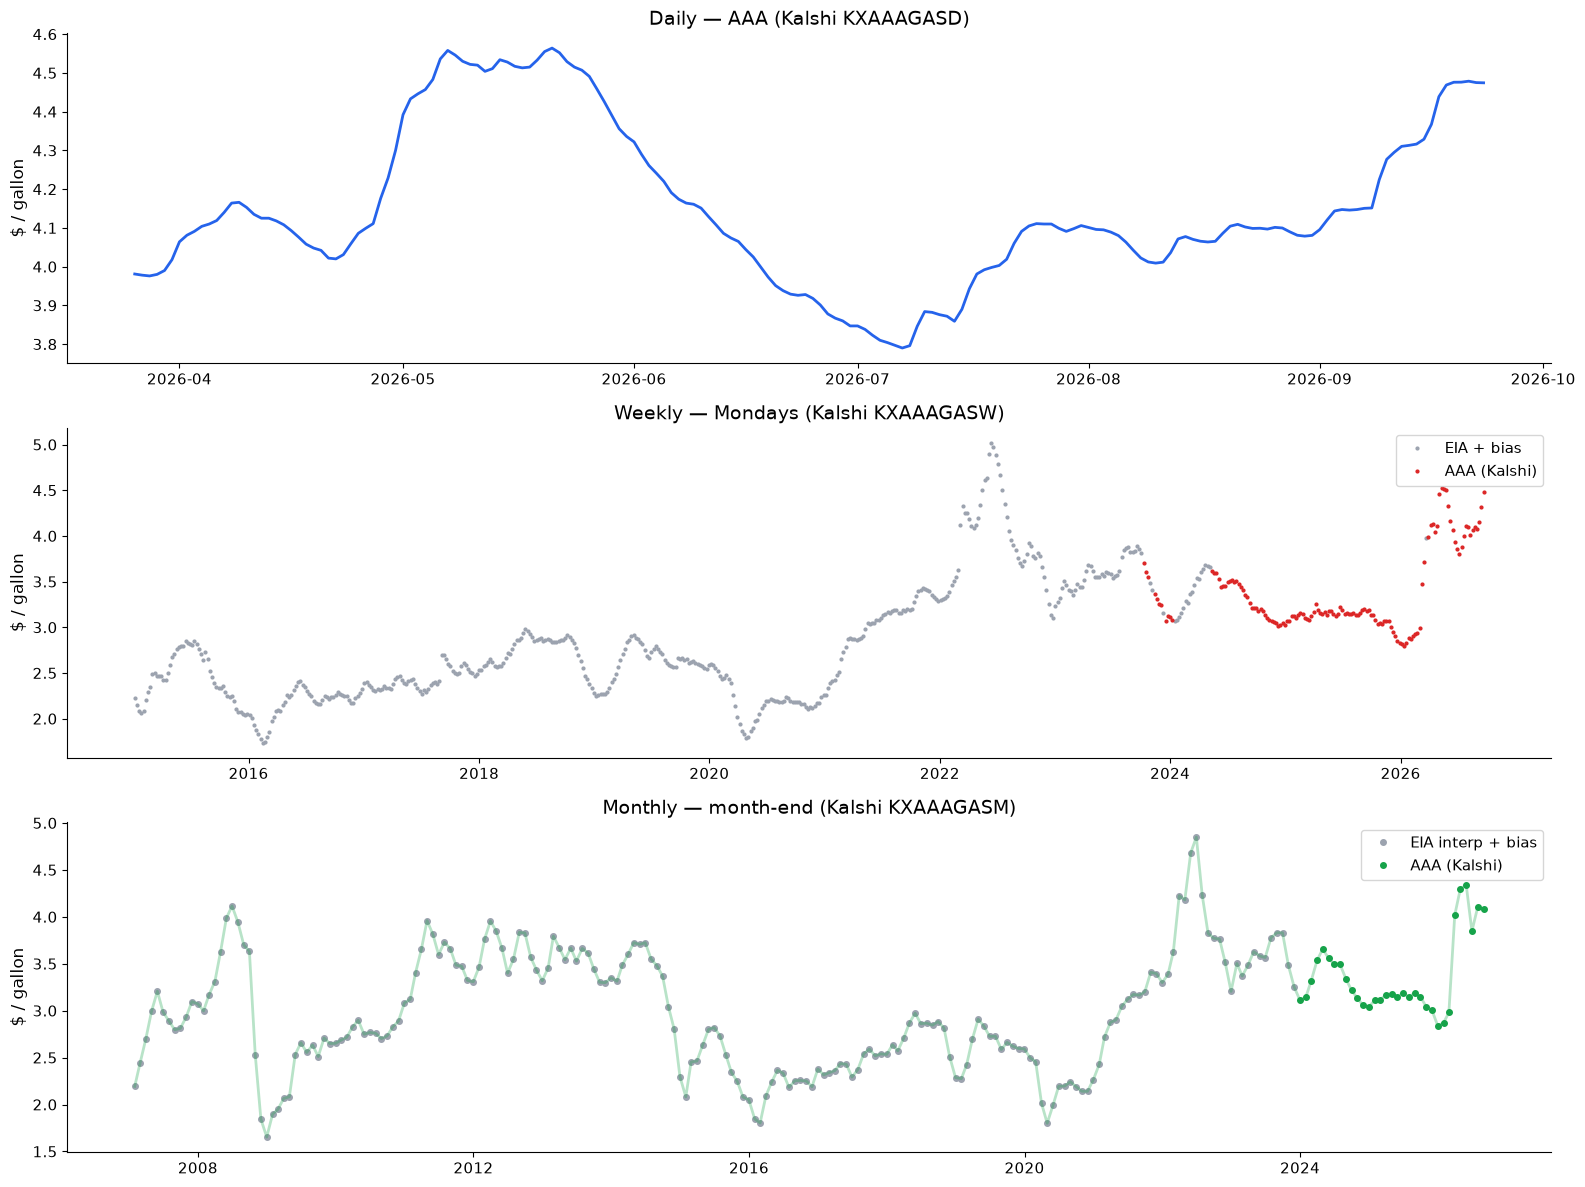

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
axes[0].plot(y_d.index, y_d.values, color="#2563eb")
axes[0].set_title(f'Daily — AAA (Kalshi {CFG["daily"]["series"]})')
for src, color in [("EIA + bias", "#9ca3af"), ("AAA (Kalshi)", "#dc2626")]:
    m = src_w == src
    axes[1].plot(y_w.index[m], y_w[m], ".", color=color, markersize=4, label=src)
axes[1].set_title(f'Weekly — Mondays (Kalshi {CFG["weekly"]["series"]})')
axes[1].legend()
for src, color in [("EIA interp + bias", "#9ca3af"), ("AAA (Kalshi)", "#16a34a")]:
    m = src_m == src
    axes[2].plot(y_m.index[m], y_m[m], "o", color=color, markersize=4, label=src)
axes[2].plot(y_m.index, y_m.values, color="#16a34a", alpha=0.3)
axes[2].set_title(f'Monthly — month-end (Kalshi {CFG["monthly"]["series"]})')
axes[2].legend()
for ax in axes:
    ax.set_ylabel("$ / gallon")
plt.tight_layout()
plt.show()

## 2.2 Retail vs wholesale — the pass-through

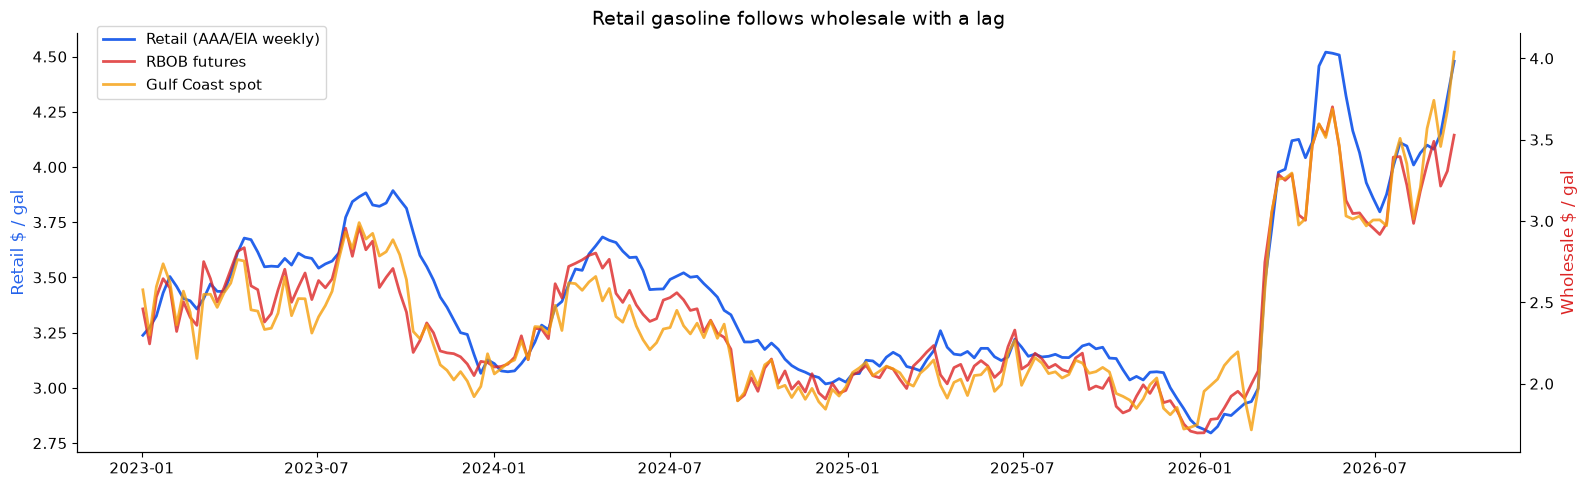

In [10]:
recent = slice("2023-01-01", None)
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(y_w[recent].index, y_w[recent], color="#2563eb", label="Retail (AAA/EIA weekly)")
ax1.set_ylabel("Retail $ / gal", color="#2563eb")
ax2 = ax1.twinx()
ax2.plot(
    X_by["weekly"][recent].index,
    X_by["weekly"]["RB=F"][recent],
    color="#dc2626",
    label="RBOB futures",
    alpha=0.8,
)
ax2.plot(
    X_by["weekly"][recent].index,
    X_by["weekly"]["DGASUSGULF"][recent],
    color="#f59e0b",
    label="Gulf Coast spot",
    alpha=0.8,
)
ax2.set_ylabel("Wholesale $ / gal", color="#dc2626")
ax2.spines["right"].set_visible(True)
fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.95))
ax1.set_title("Retail gasoline follows wholesale with a lag")
plt.tight_layout()
plt.show()

## 2.3 Year-over-Year Growth Rates

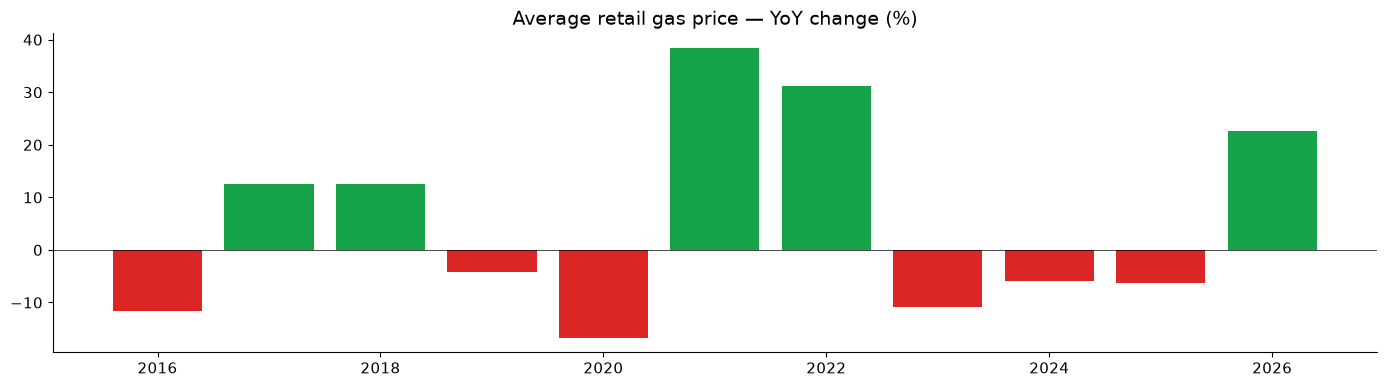

            2015    2016   2017    2018   2019    2020    2021    2022    2023   2024   2025    2026
avg_price  2.444   2.158   2.43   2.734  2.619   2.183   3.023   3.966   3.534  3.324  3.112   3.814
yoy_%        NaN -11.700  12.60  12.500 -4.200 -16.700  38.500  31.200 -10.900 -5.900 -6.400  22.500


In [11]:
annual = y_w.groupby(y_w.index.year).mean()
yoy = annual.pct_change() * 100
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(
    yoy.dropna().index,
    yoy.dropna().values,
    color=["#16a34a" if v > 0 else "#dc2626" for v in yoy.dropna().values],
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Average retail gas price — YoY change (%)")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"avg_price": annual.round(3), "yoy_%": yoy.round(1)}).T.to_string())

## 2.4 Seasonality Patterns

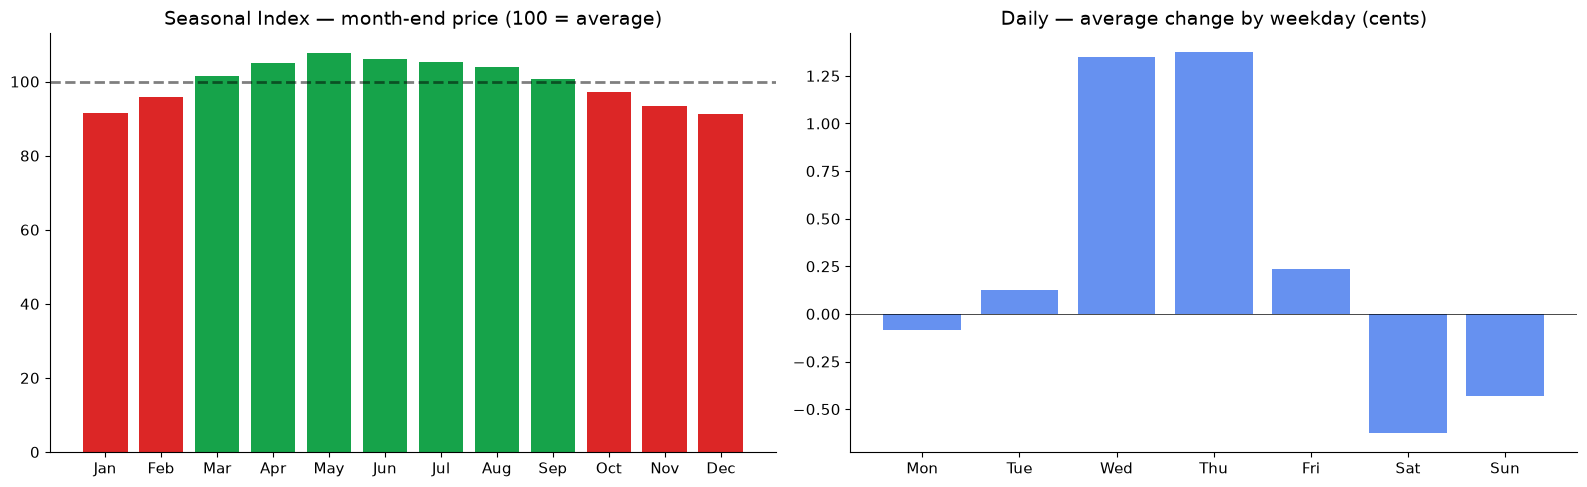

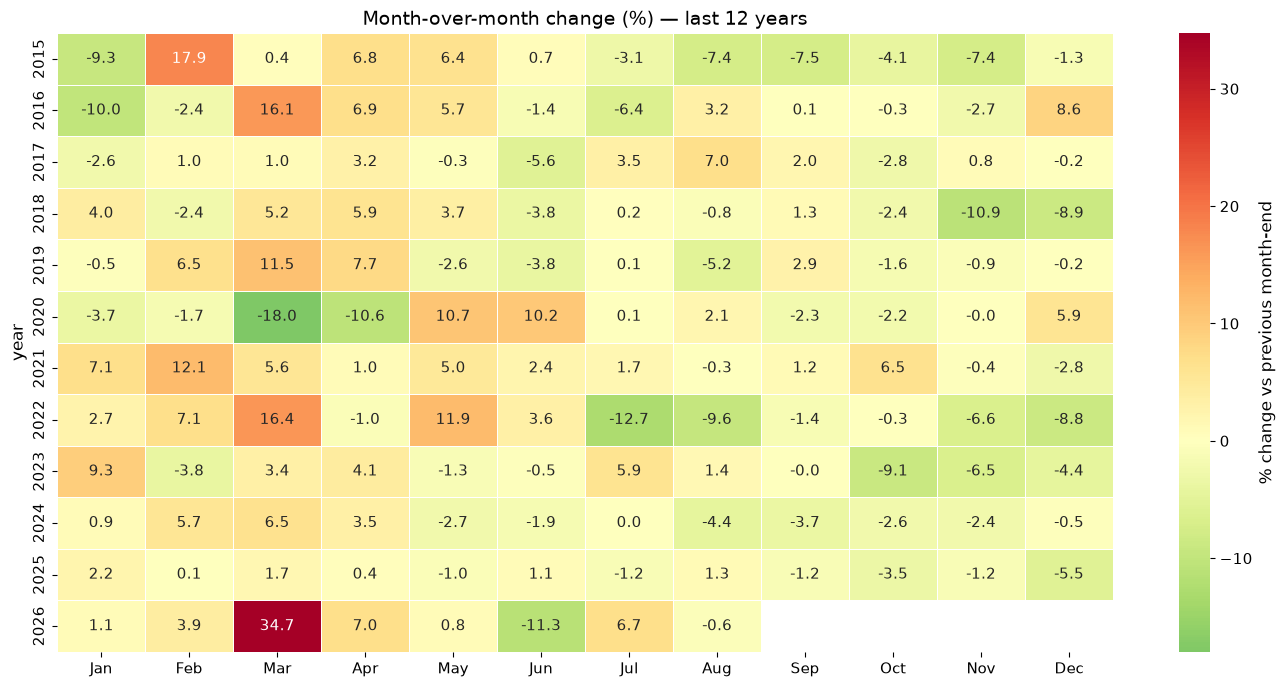

In [12]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
m_chg = y_m.pct_change() * 100
seasonal_idx = (y_m.groupby(y_m.index.month).mean() / y_m.mean() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(
    range(1, 13),
    seasonal_idx.values,
    color=["#dc2626" if v < 100 else "#16a34a" for v in seasonal_idx],
)
axes[0].axhline(100, color="black", linestyle="--", alpha=0.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title("Seasonal Index — month-end price (100 = average)")
dow = y_d.diff().groupby(y_d.index.dayofweek).mean() * 100
axes[1].bar(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color="#2563eb", alpha=0.7
)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Daily — average change by weekday (cents)")
plt.tight_layout()
plt.show()

heat = pd.DataFrame(
    {"year": m_chg.index.year, "month": m_chg.index.month, "chg": m_chg.values}
).pivot_table(index="year", columns="month", values="chg")
heat.columns = month_names[: len(heat.columns)]
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heat.tail(12),
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% change vs previous month-end"},
)
ax.set_title("Month-over-month change (%) — last 12 years")
plt.tight_layout()
plt.show()

## 2.5 Size of one-step moves

Kalshi strikes are spaced 1–2¢ apart (daily/weekly) and ~2¢ (monthly). The spread of one-step changes
tells us how many strikes are "in play" for each contract.

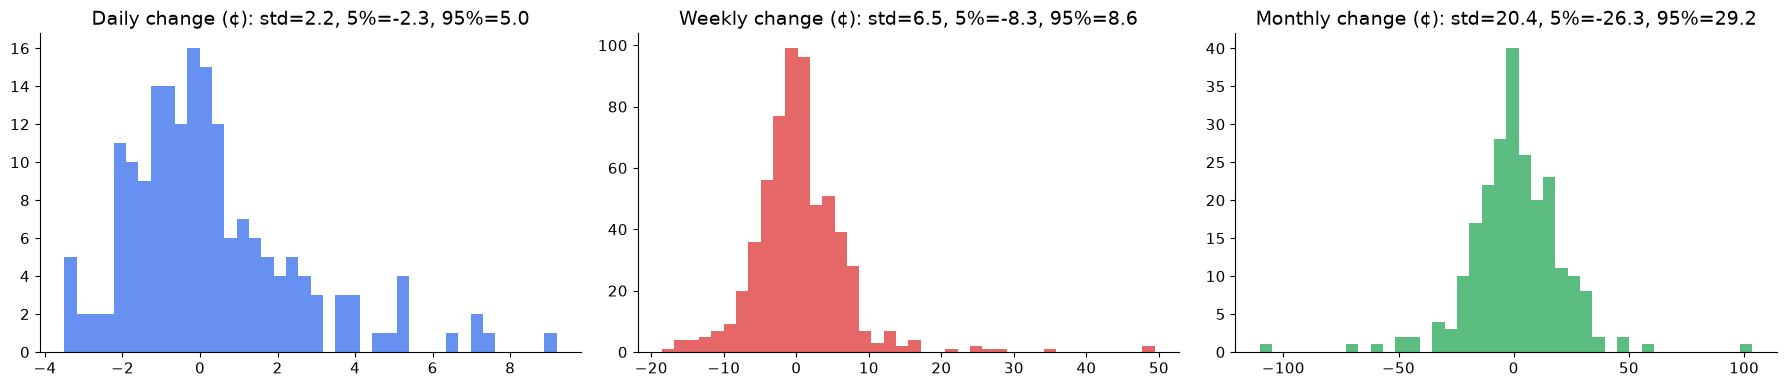

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (k, y), color in zip(axes, Y.items(), ["#2563eb", "#dc2626", "#16a34a"], strict=False):
    chg = y.diff().dropna() * 100
    ax.hist(chg, bins=40, color=color, alpha=0.7)
    ax.set_title(
        f"{k.capitalize()} change (¢): std={chg.std():.1f}, "
        f"5%={chg.quantile(.05):.1f}, 95%={chg.quantile(.95):.1f}"
    )
plt.tight_layout()
plt.show()

## 2.6 Driver discovery — which variables move *before* X?

**(a) Correlation of levels.** Shown only to demonstrate why it is misleading: trending prices correlate
with almost anything.

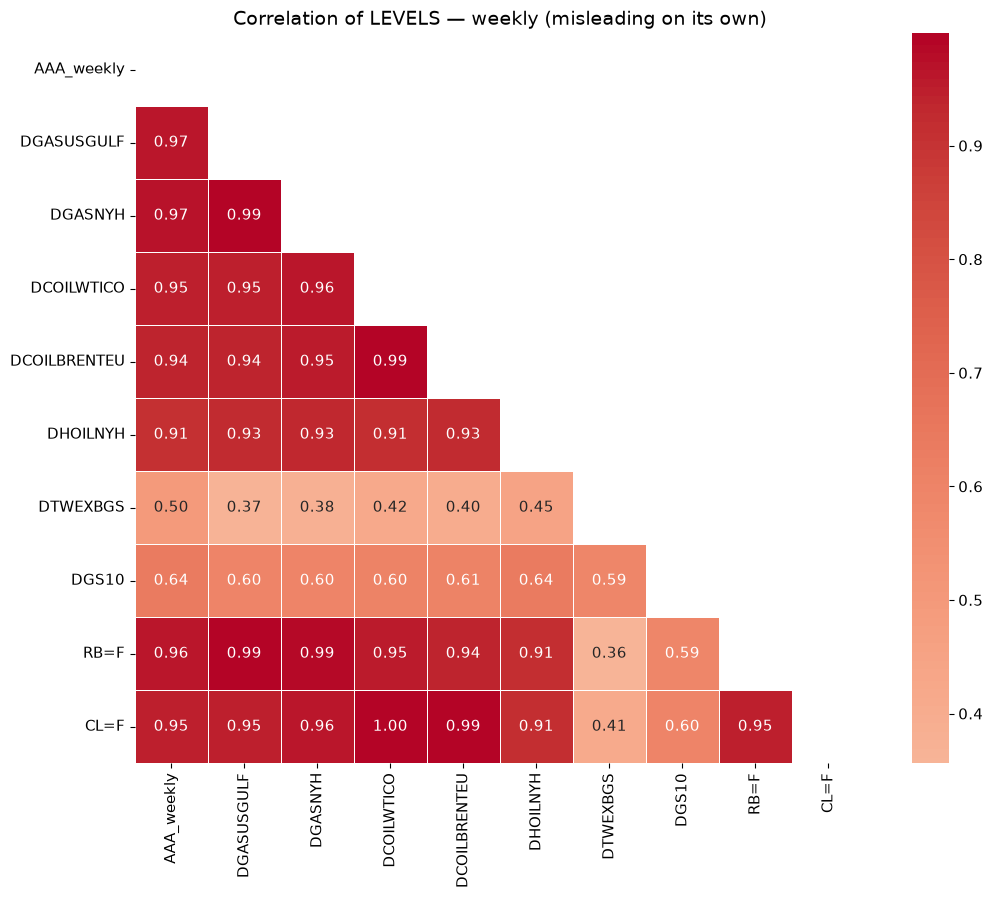

In [14]:
lvl = pd.concat([y_w.rename("AAA_weekly"), X_by["weekly"]], axis=1).dropna()
fig, ax = plt.subplots(figsize=(11, 9))
corr = lvl.corr()
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation of LEVELS — weekly (misleading on its own)")
plt.tight_layout()
plt.show()

**(b) Lead-lag correlation of changes.** corr(ΔX_t, Δdriver_{t−k}). Lag k = 0 is the week that ends the day
before the settlement Monday (known before AAA publishes, but only if we bet late). **k ≥ 1 is what a model can
use when it forecasts one full week ahead.**

**(c) Granger causality.** p-value of "past driver changes add information about future X changes"
(min over 1–4 lags).

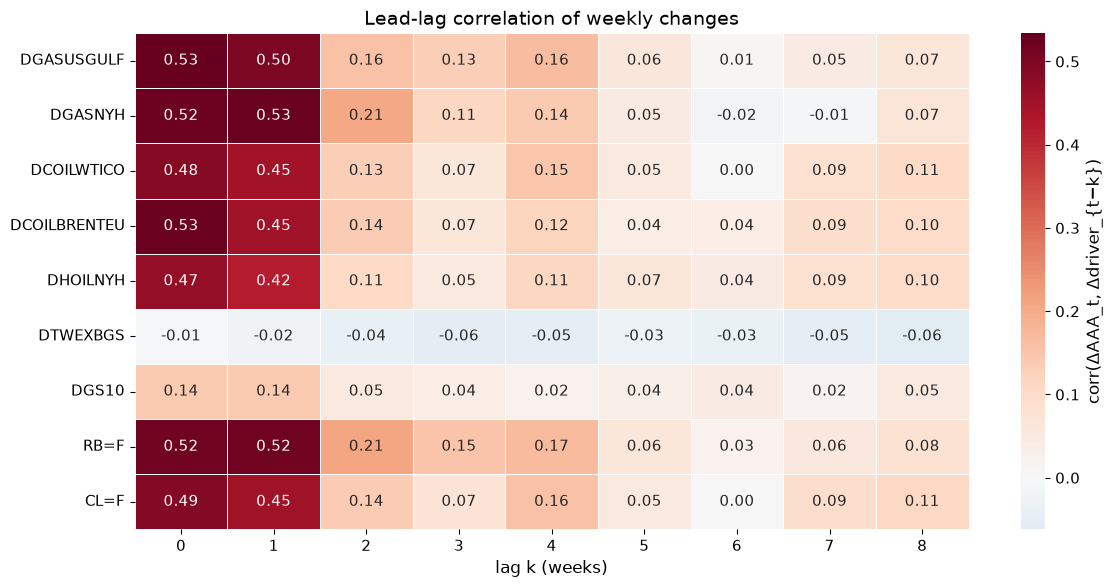

,description,level_corr,corr_k0,best_lag_k>=1,corr_best_lag,granger_p,abs_pred_corr
driver,,,,,,,
DGASNYH,NY Harbor gasoline spot (FRED),0.970,0.521,1,0.526,5.463701e-18,0.526
RB=F,RBOB gasoline futures (Yahoo),0.965,0.520,1,0.516,4.517035e-18,0.516
DGASUSGULF,Gulf Coast gasoline spot (FRED),0.965,0.534,1,0.502,1.119609e-16,0.502
DCOILBRENTEU,Brent crude spot (FRED),0.939,0.527,1,0.454,5.843670e-10,0.454
CL=F,WTI crude futures (Yahoo),0.945,0.491,1,0.452,2.708672e-11,0.452
DCOILWTICO,WTI crude spot (FRED),0.948,0.484,1,0.446,1.034762e-10,0.446
DHOILNYH,NY Harbor heating oil spot (FRED),0.911,0.469,1,0.418,2.644866e-10,0.418
DGS10,10Y Treasury yield — placebo (FRED),0.640,0.139,1,0.141,5.207417e-02,0.141
DTWEXBGS,Trade-weighted US dollar (FRED),0.497,-0.008,8,-0.062,5.714467e-01,0.062


In [15]:
dy = y_w.diff()
dX = X_by["weekly"].diff()
lags = range(0, 9)
cc = pd.DataFrame(
    {k: [dy.corr(dX[c].shift(k)) for c in dX.columns] for k in lags}, index=dX.columns
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    cc,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "corr(ΔAAA_t, Δdriver_{t−k})"},
)
ax.set_xlabel("lag k (weeks)")
ax.set_title("Lead-lag correlation of weekly changes")
plt.tight_layout()
plt.show()

rows = []
for c in dX.columns:
    data = pd.concat([dy, dX[c]], axis=1).dropna()
    with contextlib.redirect_stdout(io.StringIO()):
        gc = grangercausalitytests(data, maxlag=4)
    pred = cc.loc[c, 1:]
    rows.append(
        {
            "driver": c,
            "description": EXOG_NAMES[c],
            "level_corr": round(lvl["AAA_weekly"].corr(lvl[c]), 3),
            "corr_k0": round(cc.loc[c, 0], 3),
            "best_lag_k>=1": int(pred.abs().idxmax()),
            "corr_best_lag": round(pred.loc[pred.abs().idxmax()], 3),
            "granger_p": gc[min(gc, key=lambda lag: gc[lag][0]["ssr_ftest"][1])][0]["ssr_ftest"][1],
        }
    )
drivers = pd.DataFrame(rows).set_index("driver")
drivers["abs_pred_corr"] = drivers["corr_best_lag"].abs()
drivers.sort_values("abs_pred_corr", ascending=False)

**Selection rule.** Keep drivers with Granger p < 0.01, rank them by predictive correlation (k ≥ 1),
and skip any driver whose changes are > 0.9 correlated with one already selected (e.g. RBOB futures vs Gulf spot
carry the same information). Maximum 3 drivers.

In [16]:
SELECTED = []
for c in drivers[drivers["granger_p"] < 0.01].sort_values("abs_pred_corr", ascending=False).index:
    if all(abs(dX[c].corr(dX[s])) < 0.9 for s in SELECTED):
        SELECTED.append(c)
    if len(SELECTED) == 3:
        break

print("Selected exogenous drivers:")
for c in SELECTED:
    r = drivers.loc[c]
    print(
        f'  {c:12s} {EXOG_NAMES[c]:40s} corr@lag{r["best_lag_k>=1"]}={r["corr_best_lag"]:+.2f}  '
        f'Granger p={r["granger_p"]:.1e}'
    )
p_placebo = drivers.loc["DGS10", "granger_p"]
print(
    f'\nPlacebo DGS10: Granger p = {p_placebo:.3f} → '
    f'{"correctly rejected" if "DGS10" not in SELECTED else "WARNING: selected — filters too loose"}'
)

Selected exogenous drivers:
  DGASNYH      NY Harbor gasoline spot (FRED)           corr@lag1=+0.53  Granger p=5.5e-18
  RB=F         RBOB gasoline futures (Yahoo)            corr@lag1=+0.52  Granger p=4.5e-18
  DGASUSGULF   Gulf Coast gasoline spot (FRED)          corr@lag1=+0.50  Granger p=1.1e-16

Placebo DGS10: Granger p = 0.052 → correctly rejected


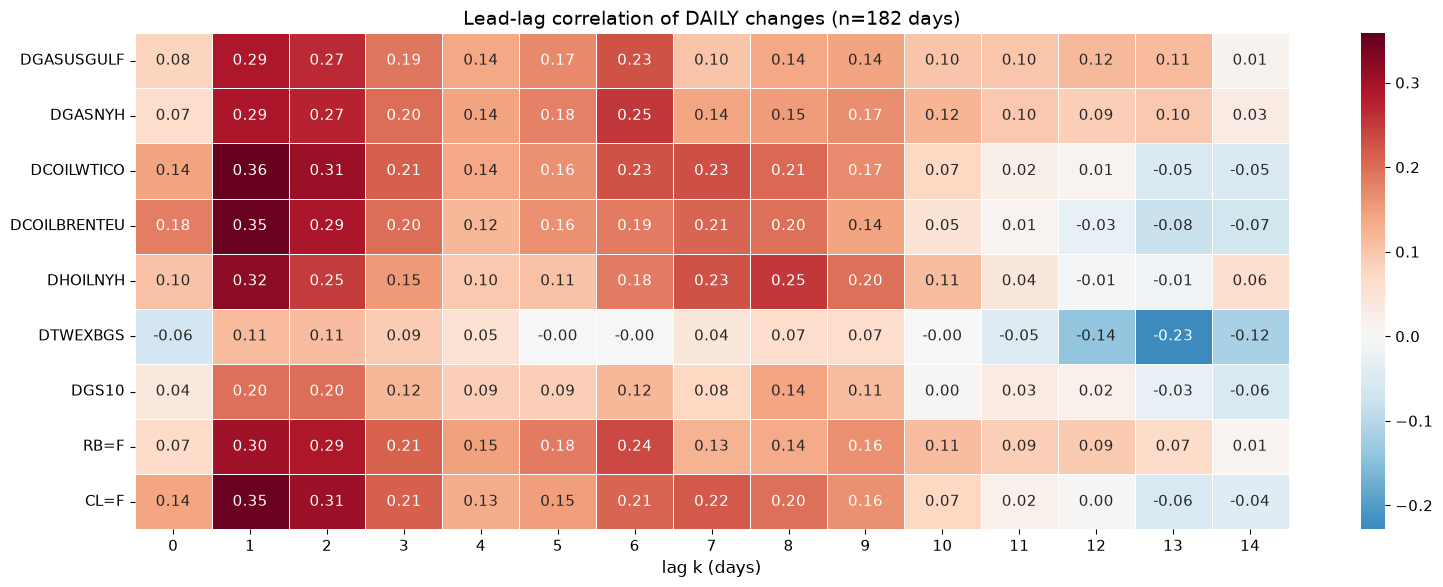

In [17]:
# Daily check: the same lead-lag view on daily changes (short sample — used to confirm, not to select)
dyd = y_d.diff()
dXd = X_by["daily"].diff()
cc_d = pd.DataFrame(
    {k: [dyd.corr(dXd[c].shift(k)) for c in dXd.columns] for k in range(0, 15)}, index=dXd.columns
)
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(cc_d, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_xlabel("lag k (days)")
ax.set_title(f"Lead-lag correlation of DAILY changes (n={len(y_d)} days)")
plt.tight_layout()
plt.show()

## 2.7 Key EDA Findings

The printed tables above carry the numbers; the pattern to look for:

| Question | Where to look |
|---------|--------|
| Is EIA a faithful proxy for AAA? | 1.2 — correlation of weekly changes and the AAA − EIA spread |
| Do wholesale prices lead retail? | 2.6 (b) — positive correlations at k ≥ 1 for gasoline spot/futures |
| Is the selection honest? | 2.6 — the placebo (10Y yield) must be rejected |
| How wide is the distribution that matters? | 2.5 — std of one-step changes in cents |

---
# Part 3: Time Series Diagnostics

**Diagnostics performed:** ADF and KPSS stationarity tests, seasonal decomposition, ACF/PACF.

> As in the original: models handle non-stationarity internally (SARIMAX via `d`/`D`, ETS via trend).
> We test stationarity to understand the data, not to difference by hand before modeling.

## 3.1 Stationarity Tests (ADF & KPSS)

In [18]:
stationarity_results = []
for k, ts in Y.items():
    adf_stat, adf_p, *_ = adfuller(ts.dropna(), autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(ts.dropna(), regression="ct")
    adf_d_p = adfuller(ts.diff().dropna(), autolag="AIC")[1]
    stationarity_results.append(
        {
            "series": k,
            "ADF_p": round(adf_p, 4),
            "ADF_result": "Stationary" if adf_p < 0.05 else "Non-stationary",
            "KPSS_p": round(kpss_p, 4),
            "KPSS_result": "Non-stationary" if kpss_p < 0.05 else "Stationary",
            "ADF_diff1_p": round(adf_d_p, 4),
            "ADF_diff1_result": "Stationary" if adf_d_p < 0.05 else "Non-stationary",
        }
    )
pd.DataFrame(stationarity_results)

,series,ADF_p,ADF_result,KPSS_p,KPSS_result,ADF_diff1_p,ADF_diff1_result
0,daily,0.4088,Non-stationary,0.0153,Non-stationary,0.0054,Stationary
1,weekly,0.4261,Non-stationary,0.0454,Non-stationary,0.0000,Stationary
2,monthly,0.0046,Stationary,0.0129,Non-stationary,0.0000,Stationary


## 3.2 Seasonal Decomposition

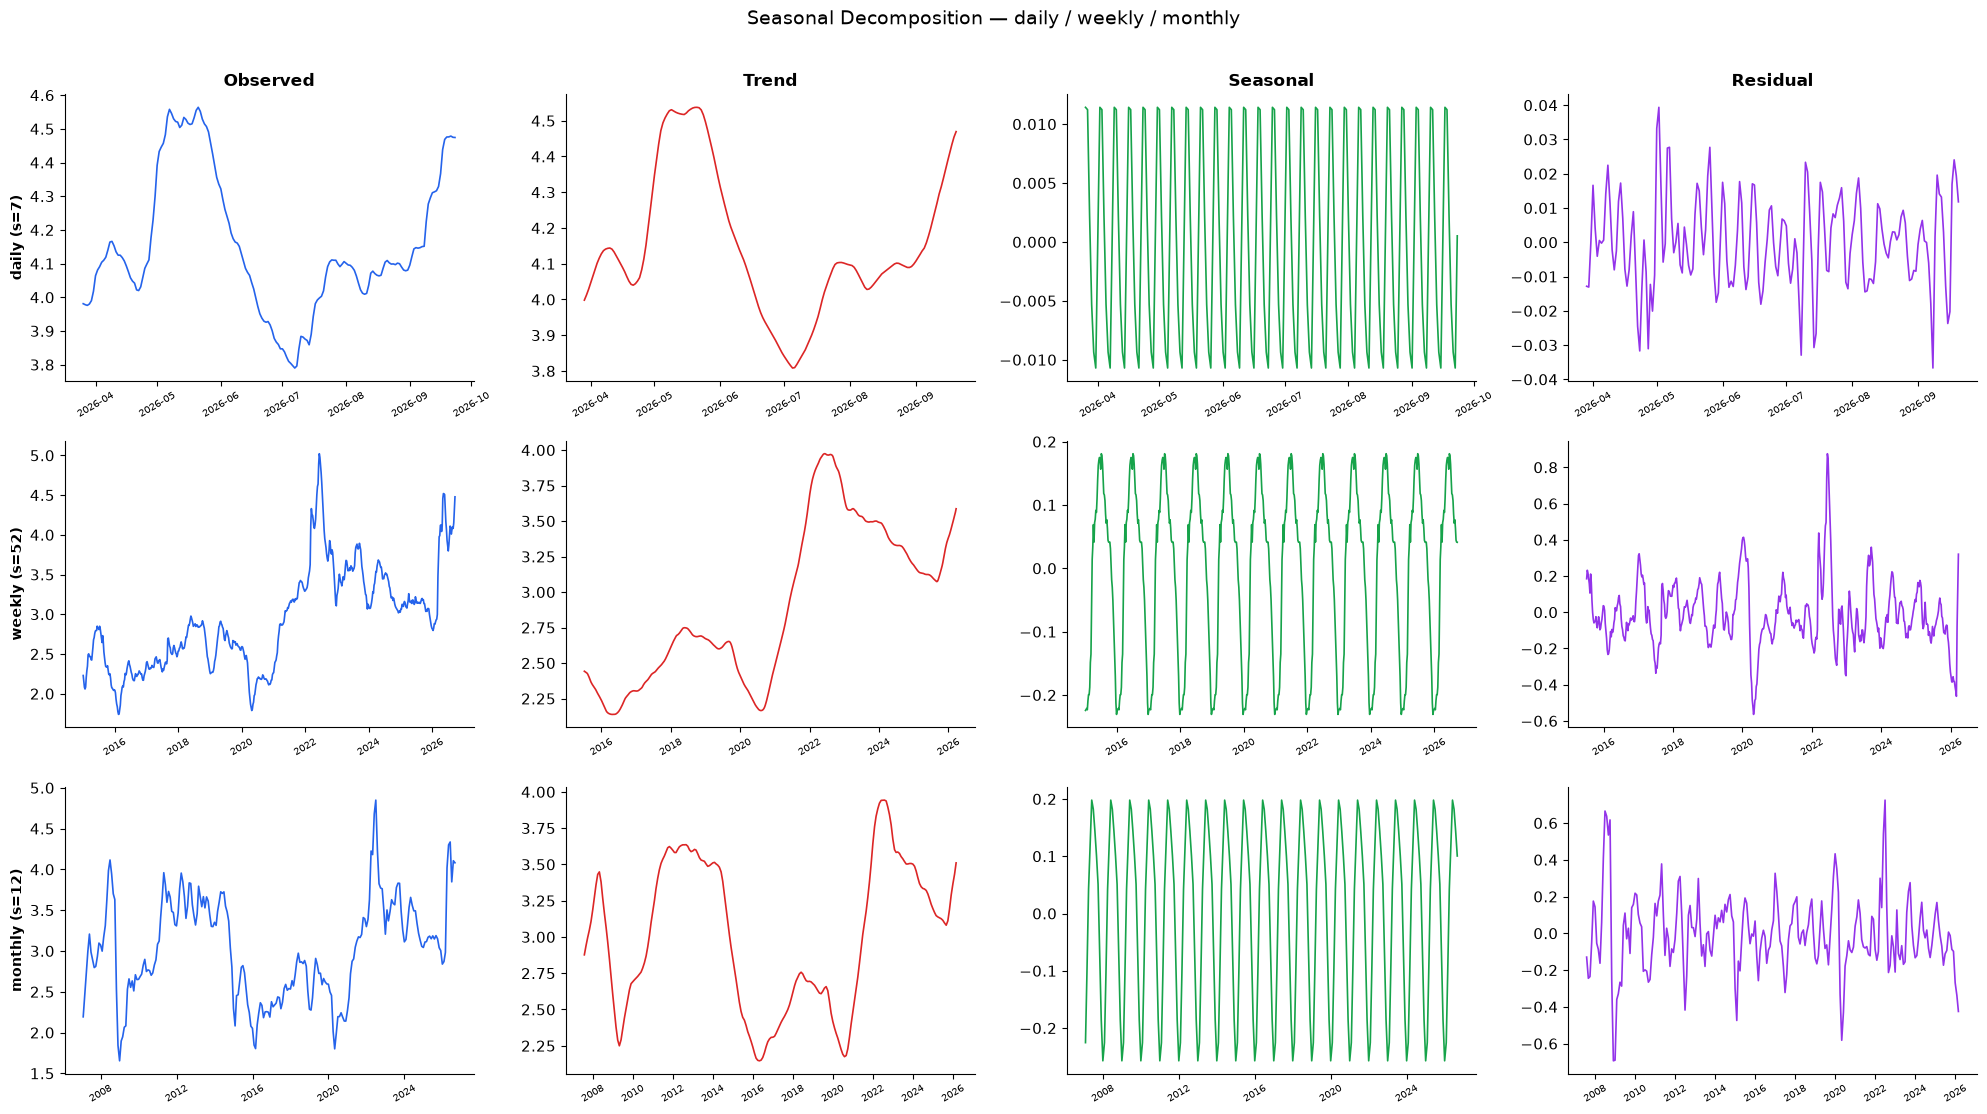

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
colors = ["#2563eb", "#dc2626", "#16a34a", "#9333ea"]
for i, (k, ts) in enumerate(Y.items()):
    decomp = seasonal_decompose(ts, model="additive", period=CFG[k]["season"])
    comps = [
        ("Observed", decomp.observed),
        ("Trend", decomp.trend),
        ("Seasonal", decomp.seasonal),
        ("Residual", decomp.resid),
    ]
    for j, ((title, data), color) in enumerate(zip(comps, colors, strict=False)):
        axes[i, j].plot(data.index, data.values, color=color, linewidth=1.2)
        if i == 0:
            axes[i, j].set_title(title, fontsize=12, fontweight="bold")
        axes[i, j].tick_params(axis="x", rotation=30, labelsize=7)
    axes[i, 0].set_ylabel(f'{k} (s={CFG[k]["season"]})', fontsize=10, fontweight="bold")
plt.suptitle("Seasonal Decomposition — daily / weekly / monthly", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3.3 ACF & PACF Analysis

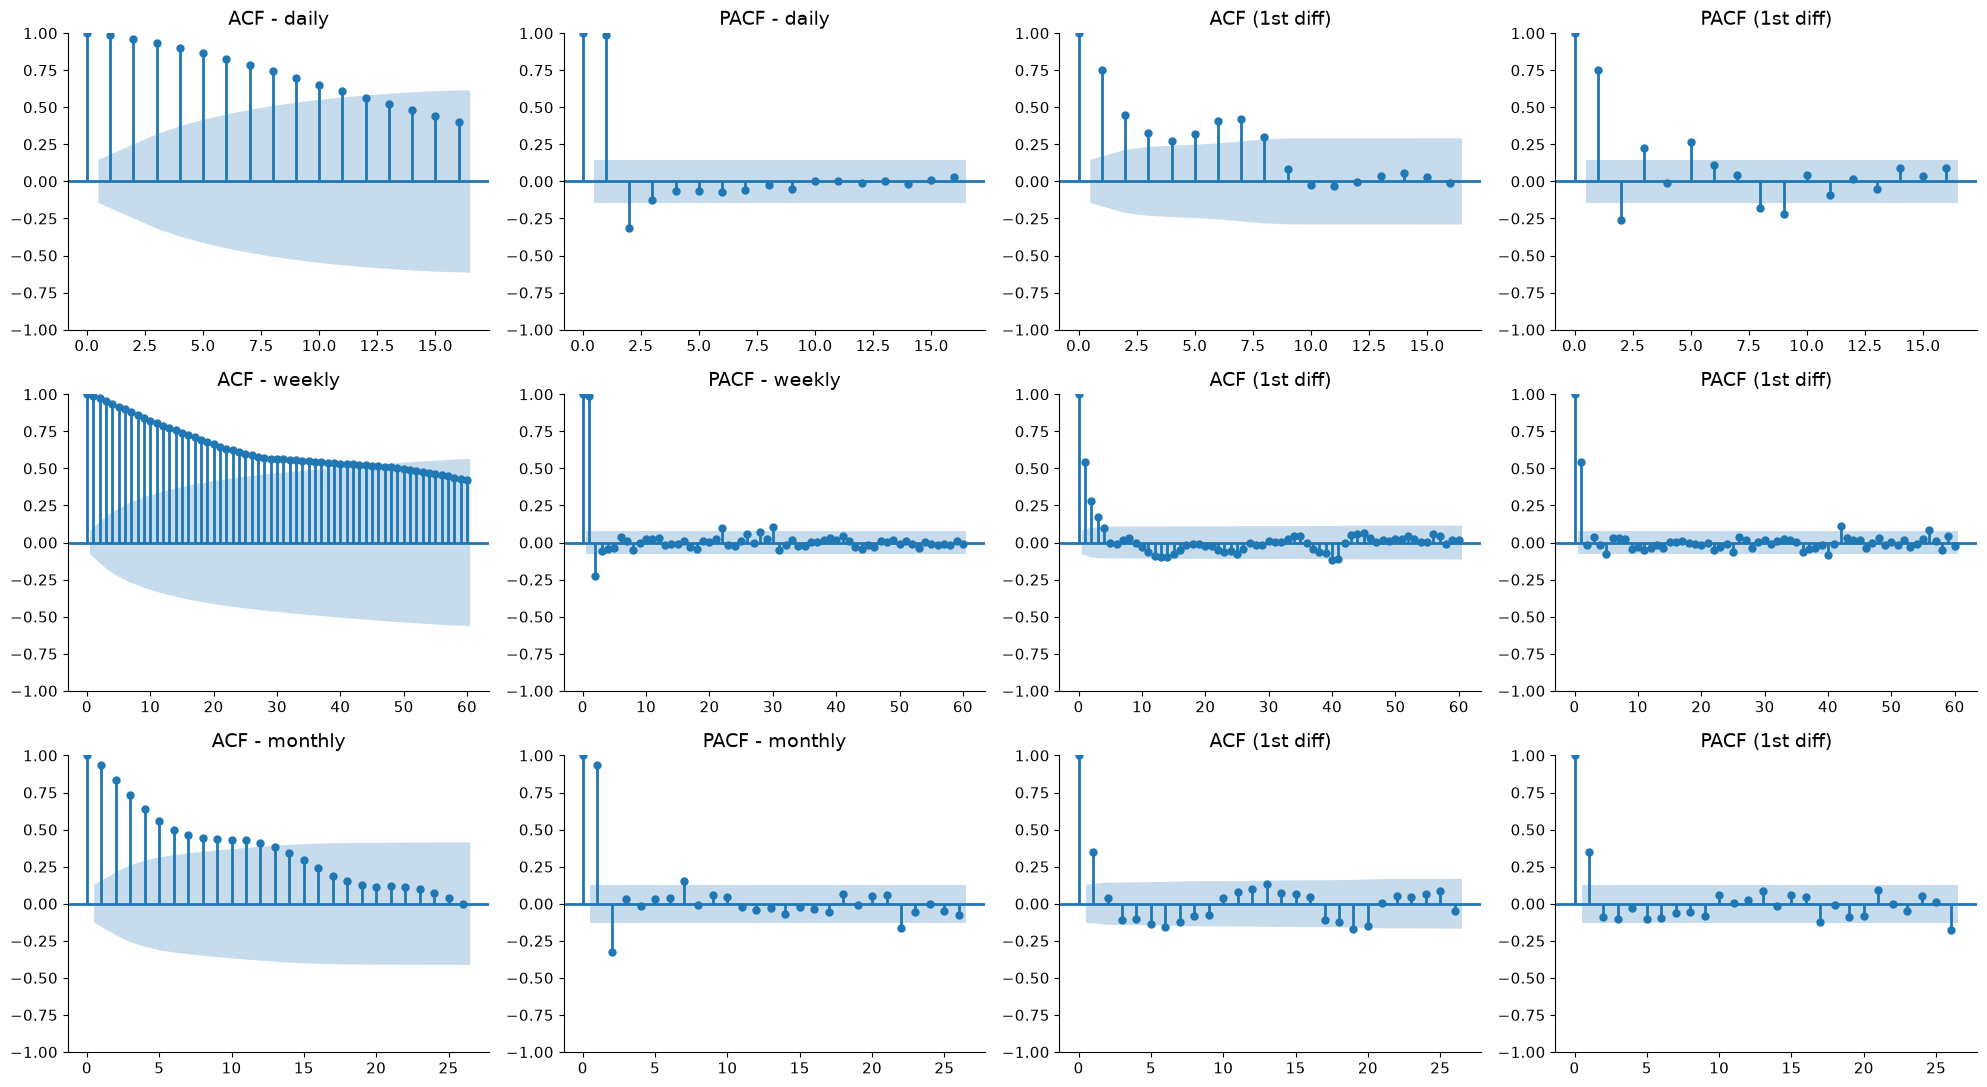

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
for i, (k, ts) in enumerate(Y.items()):
    max_lags = min(2 * CFG[k]["season"] + 2, len(ts) // 2 - 1, 60)
    plot_acf(ts, ax=axes[i, 0], lags=max_lags, title=f"ACF - {k}")
    plot_pacf(ts, ax=axes[i, 1], lags=max_lags, title=f"PACF - {k}")
    plot_acf(ts.diff().dropna(), ax=axes[i, 2], lags=max_lags, title="ACF (1st diff)")
    plot_pacf(ts.diff().dropna(), ax=axes[i, 3], lags=max_lags, title="PACF (1st diff)")
plt.tight_layout()
plt.show()

## 3.4 Automatic Differencing & Cointegration Decisions

These decisions are **computed, not chosen by hand**, and every model in Part 4 must follow them
(module `prediction_markets_forecasting.stationarity`, shared by all notebooks):

| Decision | Rule | Used by |
|---|---|---|
| `d` | Difference until ADF rejects a unit root **and** KPSS does not reject stationarity (α = 0.05); if they disagree, difference | SARIMAX, Log-SARIMAX (`d_log` on the log series), ML target |
| `D` | One seasonal difference if STL seasonal strength F_s > 0.64 | SARIMAX, Log-SARIMAX |
| Exog mode | Engle-Granger cointegration between target and each driver (both must be I(1)) | SARIMAX-X, GB-X, RF-X |

- **ecm** — cointegrated: error-correction term `(y − a − b·driver)` from t−1 plus driver changes
- **diff** — not cointegrated: driver changes only
- **level** — the target is already stationary: lagged driver levels

Why: comparing AIC across different `d` is invalid (each `d` models different data), and regressing a
non-stationary level on another without cointegration produces spurious fits.

In [21]:
DESIGN = {k: decide(Y[k], X_by[k][SELECTED], CFG[k]["season"]) for k in Y}
pd.DataFrame({k: v.summary() for k, v in DESIGN.items()}).T

,d,d_log,D,seasonal_strength,ADF_p,KPSS_p,exog_mode,ecm_driver,coint_p[DGASNYH],coint_p[RB=F],coint_p[DGASUSGULF]
daily,1,1,0,0.247,0.4088,0.1,diff,None,0.2118,0.302,0.5648
weekly,1,1,0,0.334,0.4261,0.01,ecm,DGASNYH,0.0,0.0037,0.0955
monthly,0,0,0,0.266,0.0046,0.1,level,None,NaN,NaN,NaN


---
# Part 4: Forecasting — Daily, Weekly, Monthly

### Model Overview

| Family | Model | Library | Selection Method | Key Idea |
|--------|-------|---------|-----------------|----------|
| **Statistical** | SARIMAX | statsmodels | Automatic `d`/`D` → AIC picks (p,q,P,Q) → CV | Trend + seasonality via differencing |
| **Statistical** | SARIMAX-X | statsmodels | Same order on Δy + ECM / Δdriver regressors | Wholesale pass-through without spurious levels |
| **Statistical** | Log-SARIMAX | statsmodels | AIC → CV | Variance stabilization via log |
| **Statistical** | ETS (Holt-Winters) | statsmodels | Expanding CV | 10 trend/seasonal configurations |
| **Nixtla** | AutoARIMA, AutoETS, AutoTheta, AutoCES, DynOptTheta, OptTheta, MSTL | statsforecast | Automatic + CV | Different dynamics per model |
| **ML** | Gradient Boosting, Random Forest | sklearn | Expanding CV | Lags, rolling stats, calendar sin/cos |
| **ML** | GB-X, RF-X | sklearn | Expanding CV | + lagged drivers and their changes |
| **Baseline** | Naive, Seasonal Naive, Drift | — | Expanding CV | Naive = random walk, the bar for prices |
| **Ensemble** | Average | — | CV on member predictions | Mean of best model per family |

**Cross-validation:** expanding window, one-step-ahead, the last `n_folds` periods
(daily 28 days, weekly 26 weeks, monthly 24 months). RMSE is pooled over all folds.
**Skill vs Naive** = 1 − RMSE_model / RMSE_Naive (> 0 means the model beats the random walk).

**Exogenous timing:** the driver row used to forecast period t+1 is the value known at period t (lag 1 on the
target grid), so every CV forecast only uses information that existed at the time.

## 4.1 Cross-Validation Framework

In [22]:
def mape_score(y_true, y_pred):
    # MAPE with zero protection.
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return float("inf")
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def ts_cv_rmse(full_series, model_fn, n_folds=24, val_size=1, min_train=60):
    # Expanding-window CV. Returns (RMSE, MAPE, errors, predictions).
    errs, preds = [], []
    n = len(full_series)
    for fold in range(n_folds):
        val_end = n - fold * val_size
        val_start = val_end - val_size
        if val_start < min_train:
            break
        train_part = full_series.iloc[:val_start]
        val_part = full_series.iloc[val_start:val_end]
        try:
            fc = np.asarray(model_fn(train_part), dtype=float)[:val_size]
            if len(fc) < val_size or not np.all(np.isfinite(fc)):
                continue
            errs.append(val_part.values - fc)
            preds.append(pd.Series(fc, index=val_part.index))
        except Exception:
            pass
    if not errs:
        return float("inf"), float("inf"), np.array([]), pd.Series(dtype=float)
    e = np.concatenate(errs)
    p = pd.concat(preds).sort_index()
    actual = full_series.loc[p.index]
    return float(np.sqrt(np.mean(e**2))), mape_score(actual, p), e, p


def cal_pos(idx, freq):
    # Position in the seasonal cycle for sin/cos encoding.
    if freq == "D":
        return np.asarray(idx.dayofweek), 7
    if freq == "W-MON":
        return np.asarray(idx.isocalendar().week, dtype=int), 52
    return np.asarray(idx.month), 12


def build_ml_features(series, n_lags, season, freq, X=None):
    # Lag, rolling, calendar and (optional) exogenous features — same recipe as the original notebook.
    df = pd.DataFrame({"y": series.values}, index=series.index)
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)
    df["roll_mean_3"] = df["y"].shift(1).rolling(3).mean()
    df["roll_mean_6"] = df["y"].shift(1).rolling(6).mean()
    df["roll_mean_12"] = df["y"].shift(1).rolling(12).mean()
    df["roll_std_6"] = df["y"].shift(1).rolling(6).std()
    pos, per = cal_pos(df.index, freq)
    df["cal_sin"] = np.sin(2 * np.pi * pos / per)
    df["cal_cos"] = np.cos(2 * np.pi * pos / per)
    df["yoy_change"] = df["y"].shift(season)
    if X is not None:
        for c in X.columns:
            df[f"x_{c}"] = X[c].values
            df[f"x_{c}_chg"] = X[c].diff().values
    return df.dropna()


def ml_next_row(history, next_date, n_lags, season, freq, x_next=None, x_prev=None):
    # Feature row for the next period (one-step forecast).
    h = list(history.values)
    row = {f"lag_{lag}": h[-lag] for lag in range(1, n_lags + 1)}
    row["roll_mean_3"] = np.mean(h[-3:])
    row["roll_mean_6"] = np.mean(h[-6:])
    row["roll_mean_12"] = np.mean(h[-12:])
    row["roll_std_6"] = np.std(h[-6:], ddof=1)
    pos, per = cal_pos(pd.DatetimeIndex([next_date]), freq)
    row["cal_sin"] = np.sin(2 * np.pi * pos[0] / per)
    row["cal_cos"] = np.cos(2 * np.pi * pos[0] / per)
    row["yoy_change"] = h[-season]
    if x_next is not None:
        for c in x_next.index:
            row[f"x_{c}"] = x_next[c]
            row[f"x_{c}_chg"] = x_next[c] - x_prev[c]
    return row


print("Cross-validation framework + ML feature builder ready.")

Cross-validation framework + ML feature builder ready.


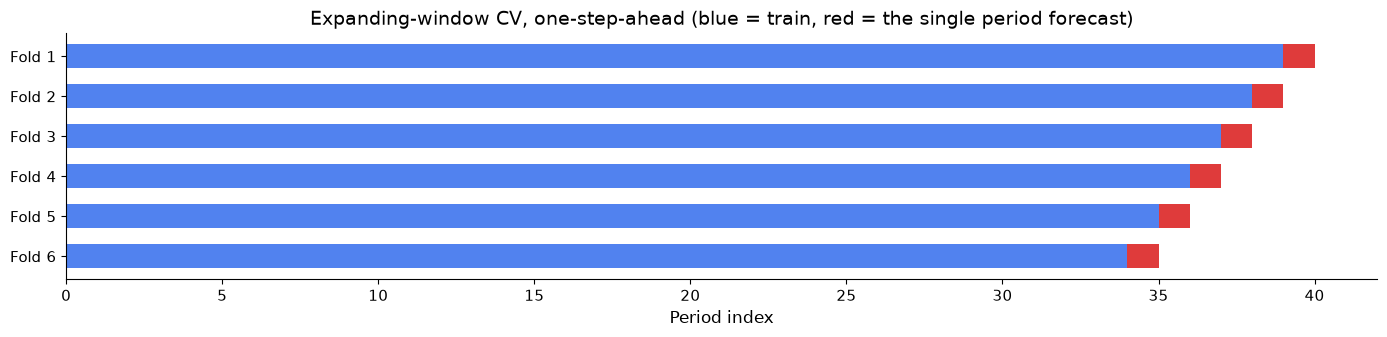

In [23]:
# Visualize the one-step expanding-window CV (weekly example)
fig, ax = plt.subplots(figsize=(14, 3.5))
n_show, folds_show = 40, 6
for f in range(folds_show):
    train_end = n_show - folds_show + f
    ax.barh(f, train_end, color="#2563eb", alpha=0.8, height=0.6)
    ax.barh(f, 1, left=train_end, color="#dc2626", alpha=0.9, height=0.6)
ax.set_yticks(range(folds_show))
ax.set_yticklabels([f"Fold {folds_show - f}" for f in range(folds_show)])
ax.set_xlabel("Period index")
ax.set_title("Expanding-window CV, one-step-ahead (blue = train, red = the single period forecast)")
plt.tight_layout()
plt.show()

## 4.2 Model Configurations

In [24]:
# SARIMAX focused grid (same 24 orders as the original notebook); seasonal period s set per frequency
sarimax_configs = [
    (0, 1, 1, 0, 1, 1),
    (0, 1, 1, 1, 1, 1),
    (0, 1, 2, 0, 1, 1),
    (0, 1, 2, 1, 1, 1),
    (1, 1, 1, 0, 1, 1),
    (1, 1, 1, 1, 1, 1),
    (1, 1, 2, 0, 1, 1),
    (1, 1, 2, 1, 1, 1),
    (2, 1, 1, 0, 1, 1),
    (2, 1, 1, 1, 1, 1),
    (2, 1, 2, 0, 1, 1),
    (2, 1, 2, 1, 1, 1),
    (0, 0, 1, 1, 0, 1),
    (0, 0, 2, 1, 0, 1),
    (1, 0, 0, 1, 0, 0),
    (1, 0, 1, 1, 0, 0),
    (1, 0, 1, 1, 0, 1),
    (2, 0, 0, 1, 0, 0),
    (2, 0, 1, 1, 0, 0),
    (2, 0, 1, 1, 0, 1),
    (0, 1, 0, 1, 0, 0),
    (0, 1, 0, 0, 1, 1),
    (1, 0, 0, 0, 1, 1),
    (1, 1, 0, 0, 1, 1),
]
ets_configs = [
    ("add", False, "add", "ETS(A,A,A)"),
    ("add", True, "add", "ETS(A,Ad,A)"),
    ("mul", False, "add", "ETS(A,M,A)"),
    ("mul", True, "add", "ETS(A,Md,A)"),
    ("add", False, "mul", "ETS(M,A,M)"),
    ("add", True, "mul", "ETS(M,Ad,M)"),
    ("mul", False, "mul", "ETS(M,M,M)"),
    ("mul", True, "mul", "ETS(M,Md,M)"),
    (None, False, "add", "ETS(A,N,A)"),
    (None, False, "mul", "ETS(M,N,M)"),
]
nixtla_map = {
    "AutoARIMA": AutoARIMA,
    "AutoETS": NixtlaAutoETS,
    "AutoTheta": AutoTheta,
    "AutoCES": AutoCES,
    "DynOptTheta": DynamicOptimizedTheta,
    "OptTheta": OptimizedTheta,
    "MSTL": MSTL,
}
ml_templates = [
    (
        "GradientBoosting",
        GradientBoostingRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
        ),
    ),
    ("RandomForest", RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)),
]
print(
    f"SARIMAX configs: {len(sarimax_configs)} | ETS configs: {len(ets_configs)} | "
    f"Nixtla: {len(nixtla_map)} | ML: {len(ml_templates)} (+ X variants)"
)
print(f"Exogenous drivers: {SELECTED}")

SARIMAX configs: 24 | ETS configs: 10 | Nixtla: 7 | ML: 2 (+ X variants)
Exogenous drivers: ['DGASNYH', 'RB=F', 'DGASUSGULF']


## 4.3 Forecasting Loop — Daily, Weekly, Monthly

In [25]:
def run_tournament(name, y_full, X_full, cfg, design):
    freq, s, n_folds, min_train, n_lags = (
        cfg["freq"],
        cfg["season"],
        cfg["n_folds"],
        cfg["min_train"],
        cfg["n_lags"],
    )
    step = pd.tseries.frequencies.to_offset(freq)
    Xk = X_full[design.drivers]  # each driver's value known at each target date
    next_date = y_full.index[-1] + step
    ts = y_full[Xk.notna().all(axis=1)] if design.drivers else y_full
    print(
        f"Length: {len(ts)} | {ts.index.min():%Y-%m-%d} → {ts.index.max():%Y-%m-%d} "
        f"| next target date: {next_date:%Y-%m-%d}"
    )
    print(
        f"  Automatic design: d={design.d}, d_log={design.d_log}, D={design.D}, "
        f"exog mode={design.exog_mode}"
        + (f" (ECM on {design.coint_driver})" if design.coint_driver else "")
    )

    results, cv_err, cv_pred, forecasts = [], {}, {}, {}
    scale_factor = max(ts.mean() / 1000, 1)

    def record(model, mtype, fn, exog=False, aic=np.nan):
        rmse, mape, e, p = ts_cv_rmse(ts, fn, n_folds=n_folds, val_size=1, min_train=min_train)
        if rmse < float("inf"):
            results.append(
                {
                    "Model": model,
                    "Type": mtype,
                    "CV_RMSE": rmse,
                    "MAPE": mape,
                    "n_cv": len(e),
                    "AIC": aic,
                    "Exog": exog,
                }
            )
            cv_err[model], cv_pred[model] = e, p
            try:
                forecasts[model] = float(np.asarray(fn(ts))[0])
            except Exception:
                pass

    # 1-2. SARIMAX & Log-SARIMAX — d and D come from the automatic tests (Part 3.4); AIC only compares
    #      (p, q, P, Q) orders that share the same differencing, which is what makes AIC comparable
    for log in (False, True):
        d_use = design.d_log if log else design.d
        grid = sorted({(p, d_use, q, P, design.D, Q) for (p, _, q, P, _, Q) in sarimax_configs})
        y_fit = np.log(ts / scale_factor) if log else ts / scale_factor
        res = []
        for p, d, q, P, D, Q in grid:
            try:
                fit = SARIMAX(
                    y_fit,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=100)
                if np.isfinite(fit.aic):
                    res.append(((p, d, q), (P, D, Q, s), fit.aic))
            except Exception:
                pass
        if not res:
            continue
        order, seas, aic = min(res, key=lambda r: r[2])

        def make_sarimax(log=log, order=order, seas=seas):
            def fn(tr):
                yy = np.log(tr / scale_factor) if log else tr / scale_factor
                fit = SARIMAX(
                    yy,
                    order=order,
                    seasonal_order=seas,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=100)
                fc = np.asarray(fit.forecast(1), dtype=float)
                return (np.exp(fc) if log else fc) * scale_factor

            return fn

        label = "LogSARIMAX" if log else "SARIMAX"
        record(f"{label}{order}x{seas}", label, make_sarimax(), aic=aic)
        print(
            f"  {label}: {len(grid)} orders with d={d_use}, D={design.D} → best AIC {order}x{seas} (AIC={aic:.1f})"
        )

        if not log and design.drivers:
            # SARIMAX-X: model the differenced target with ECM / driver-change regressors,
            # never raw non-stationary levels (avoids spurious regression)
            def make_sarimax_x(order=order, seas=seas):
                def fn(tr):
                    feats, coef = exog_features(tr, Xk, design)
                    if design.d >= 1:
                        w, o = tr.diff(), (order[0], order[1] - 1, order[2])
                    else:
                        w, o = tr, order
                    df = pd.concat([w.rename("w"), feats], axis=1).dropna()
                    fit = SARIMAX(
                        df["w"].values,
                        order=o,
                        seasonal_order=seas,
                        exog=df.drop(columns="w").values,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False, maxiter=100)
                    nxt = exog_next(tr, Xk, design, coef)[df.columns.drop("w")]
                    fc = float(np.asarray(fit.forecast(1, exog=nxt.values))[0])
                    return np.array([tr.iloc[-1] + fc if design.d >= 1 else fc])

                return fn

            record(
                f"SARIMAX-X[{design.exog_mode}]{order}x{seas}",
                "SARIMAX",
                make_sarimax_x(),
                exog=True,
            )

    # 3. ETS
    for trend, damped, seasonal_type, ets_name in ets_configs:

        def make_ets(t=trend, dd=damped, ss=seasonal_type):
            def fn(tr):
                m = ExponentialSmoothing(
                    tr, trend=t, damped_trend=dd if t else False, seasonal=ss, seasonal_periods=s
                )
                return m.fit(optimized=True).forecast(1).values

            return fn

        record(ets_name, "ETS", make_ets())

    # 4. Nixtla
    for nx_name, nx_cls in nixtla_map.items():

        def make_nx(cls=nx_cls):
            def fn(tr):
                sf = StatsForecast(models=[cls(season_length=s)], freq=freq, n_jobs=1)
                sf.fit(
                    pd.DataFrame({"unique_id": 0.0, "ds": tr.index, "y": tr.values.astype(float)})
                )
                fc = sf.predict(h=1)
                return fc[[c for c in fc.columns if c not in ("ds", "unique_id")][0]].values

            return fn

        record(f"Nixtla_{nx_name}", "Nixtla", make_nx())
    print(f'  Nixtla: {sum(r["Type"] == "Nixtla" for r in results)}/7 models evaluated')

    # 5. ML — when the series is non-stationary (d >= 1) the trees predict the CHANGE and we add it back
    #    to the last level (trees cannot extrapolate beyond the levels seen in training)
    for ml_name, tmpl in ml_templates:
        for use_x in (False, True) if design.drivers else (False,):

            def make_ml(tmpl=tmpl, use_x=use_x):
                def fn(tr):
                    target = (tr.diff() if design.d >= 1 else tr).dropna()
                    feat = build_ml_features(target, n_lags, s, freq)
                    if use_x:
                        xf, coef = exog_features(tr, Xk, design)
                        feat = feat.join(xf, how="inner").dropna()
                    if len(feat) < 30:
                        return None
                    X_ = feat.drop(columns=["y"])
                    model = clone(tmpl).fit(X_, feat["y"])
                    row = ml_next_row(target, tr.index[-1] + step, n_lags, s, freq)
                    if use_x:
                        row.update(exog_next(tr, Xk, design, coef).iloc[0].to_dict())
                    pred = float(model.predict(pd.DataFrame([row])[X_.columns])[0])
                    return np.array([tr.iloc[-1] + pred if design.d >= 1 else pred])

                return fn

            record(ml_name + ("-X" if use_x else ""), "ML", make_ml(), exog=use_x)

    # 6. Baselines
    record("Naive", "Baseline", lambda tr: tr.values[-1:])
    record("SeasonalNaive", "Baseline", lambda tr: np.array([tr.values[-s]]))
    for frac in [0.25, 0.50, 0.75]:
        record(
            f"Drift_{int(frac * 100)}pct",
            "Baseline",
            lambda tr, f=frac: np.array([tr.values[-s] + (tr.values[-s] - tr.values[-2 * s]) * f]),
        )

    # Ensemble: best model per family, scored on the dates every member forecast
    rk = pd.DataFrame(results)
    fam_best = [
        rk[rk["Type"] == t].sort_values("CV_RMSE")["Model"].iloc[0]
        for t in ["SARIMAX", "LogSARIMAX", "ETS", "ML"]
        if (rk["Type"] == t).any()
    ]
    members = fam_best + [
        m
        for m in [
            "Nixtla_AutoARIMA",
            "Nixtla_AutoCES",
            "Nixtla_DynOptTheta",
            "Nixtla_MSTL",
            "Naive",
        ]
        if m in cv_pred
    ]
    P = pd.concat({m: cv_pred[m] for m in members}, axis=1).dropna()
    ens = P.mean(axis=1)
    e = ts.loc[ens.index].values - ens.values
    results.append(
        {
            "Model": "Ensemble",
            "Type": "Ensemble",
            "CV_RMSE": float(np.sqrt(np.mean(e**2))),
            "MAPE": mape_score(ts.loc[ens.index], ens),
            "n_cv": len(e),
            "AIC": np.nan,
            "Exog": any("-X" in m for m in members),
        }
    )
    cv_err["Ensemble"], cv_pred["Ensemble"] = e, ens
    forecasts["Ensemble"] = float(np.mean([forecasts[m] for m in members if m in forecasts]))

    ranking = pd.DataFrame(results).sort_values("CV_RMSE").reset_index(drop=True)
    ranking.index += 1
    naive_rmse = ranking.loc[ranking["Model"] == "Naive", "CV_RMSE"].iloc[0]
    ranking["Skill_vs_Naive"] = 1 - ranking["CV_RMSE"] / naive_rmse
    ranking["Forecast"] = ranking["Model"].map(forecasts)
    best = ranking.iloc[0]
    print(
        f'  >> Best CV: {best["Model"]} (RMSE={best["CV_RMSE"]*100:.2f}¢, MAPE={best["MAPE"]:.2f}%, '
        f'skill vs Naive={best["Skill_vs_Naive"]:+.1%}) → next = ${best["Forecast"]:.4f}'
    )
    return {
        "ranking": ranking,
        "cv_err": cv_err,
        "cv_pred": cv_pred,
        "forecasts": forecasts,
        "members": members,
        "next_date": next_date,
        "ts": ts,
    }


T = {}
for k in ["daily", "weekly", "monthly"]:
    t0 = time.time()
    print(f'\n{"=" * 70}\n{k.upper()} — {CFG[k]["series"]}\n{"=" * 70}')
    T[k] = run_tournament(k, Y[k], X_by[k], CFG[k], DESIGN[k])
    print(f"  ({time.time() - t0:.0f}s)")


DAILY — KXAAAGASD
Length: 182 | 2026-03-26 → 2026-09-23 | next target date: 2026-09-24
  Automatic design: d=1, d_log=1, D=0, exog mode=diff


/Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/.venv.nosync/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/.venv.nosync/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  SARIMAX: 19 orders with d=1, D=0 → best AIC (1, 1, 1)x(1, 0, 0, 7) (AIC=-989.4)


/Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/.venv.nosync/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


...

  SARIMAX: 19 orders with d=0, D=0 → best AIC (1, 0, 1)x(1, 0, 1, 12) (AIC=-96.7)


/Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/.venv.nosync/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  LogSARIMAX: 19 orders with d=0, D=0 → best AIC (1, 0, 1)x(1, 0, 1, 12) (AIC=-587.2)


  Nixtla: 7/7 models evaluated


  >> Best CV: SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12) (RMSE=22.26¢, MAPE=2.84%, skill vs Naive=+12.6%) → next = $4.3248
  (56s)


## 4.4 Model Rankings & Comparison

In [26]:
print("=" * 100)
print("BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE")
print("=" * 100)
summary = pd.DataFrame(
    [
        {
            "frequency": k,
            "kalshi": CFG[k]["series"],
            "best_model": t["ranking"].iloc[0]["Model"],
            "type": t["ranking"].iloc[0]["Type"],
            "CV_RMSE_¢": t["ranking"].iloc[0]["CV_RMSE"] * 100,
            "MAPE_%": t["ranking"].iloc[0]["MAPE"],
            "skill_vs_naive": t["ranking"].iloc[0]["Skill_vs_Naive"],
            "naive_RMSE_¢": t["ranking"].loc[t["ranking"]["Model"] == "Naive", "CV_RMSE"].iloc[0]
            * 100,
            "next_date": t["next_date"].date(),
            "forecast": t["ranking"].iloc[0]["Forecast"],
        }
        for k, t in T.items()
    ]
)
summary.round(4)

BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE


,frequency,kalshi,best_model,type,CV_RMSE_¢,MAPE_%,skill_vs_naive,naive_RMSE_¢,next_date,forecast
0,daily,KXAAAGASD,"ETS(M,Ad,M)",ETS,1.6283,0.2321,0.3574,2.5338,2026-09-24,4.4759
1,weekly,KXAAAGASW,RandomForest-X,ML,9.0114,1.7329,0.2268,11.6554,2026-09-28,4.5901
2,monthly,KXAAAGASM,"SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12)",SARIMAX,22.2624,2.8363,0.1262,25.4772,2026-09-30,4.3248


In [27]:
for k, t in T.items():
    r = t["ranking"].copy()
    r["CV_RMSE_¢"] = r["CV_RMSE"] * 100
    print(f'\n{"=" * 80}\n{k.upper()} — full ranking\n{"=" * 80}')
    print(
        r[["Model", "Type", "Exog", "CV_RMSE_¢", "MAPE", "Skill_vs_Naive", "n_cv", "Forecast"]]
        .round(4)
        .to_string()
    )


DAILY — full ranking
                                    Model        Type   Exog  CV_RMSE_¢    MAPE  Skill_vs_Naive  n_cv  Forecast
1                             ETS(M,Ad,M)         ETS  False     1.6283  0.2321          0.3574    28    4.4759
2                             ETS(M,Md,M)         ETS  False     1.6316  0.2334          0.3561    28    4.4759
3                             ETS(A,Ad,A)         ETS  False     1.6317  0.2330          0.3560    28    4.4759
4                      GradientBoosting-X          ML   True     1.6486  0.2176          0.3494    28    4.4723
5                                Ensemble    Ensemble   True     1.7288  0.2270          0.3177    28    4.4854
6                              ETS(M,A,M)         ETS  False     1.7437  0.2612          0.3118    28    4.4733
7                              ETS(A,A,A)         ETS  False     1.7476  0.2609          0.3103    28    4.4735
8                          RandomForest-X          ML   True     1.7506  0.2306   

### Does the exogenous driver add value?

Same model with and without drivers, same CV folds. Negative Δ = the driver **lowers** the error.

In [28]:
pairs = [
    ("SARIMAX", "SARIMAX-X"),
    ("GradientBoosting", "GradientBoosting-X"),
    ("RandomForest", "RandomForest-X"),
]
rows = []
for k, t in T.items():
    r = t["ranking"].set_index("Model")["CV_RMSE"]
    for a, b in pairs:
        ma = [m for m in r.index if m.startswith(a) and "-X" not in m]
        mb = [m for m in r.index if m.startswith(b)]
        if ma and mb:
            rows.append(
                {
                    "frequency": k,
                    "model": a,
                    "without_¢": r[ma[0]] * 100,
                    "with_X_¢": r[mb[0]] * 100,
                    "Δ_¢": (r[mb[0]] - r[ma[0]]) * 100,
                    "improves": r[mb[0]] < r[ma[0]],
                }
            )
pd.DataFrame(rows).round(3)

,frequency,model,without_¢,with_X_¢,Δ_¢,improves
0,daily,SARIMAX,1.846,1.819,-0.027,True
1,daily,GradientBoosting,1.774,1.649,-0.125,True
2,daily,RandomForest,1.790,1.751,-0.040,True
3,weekly,SARIMAX,10.482,9.349,-1.133,True
4,weekly,GradientBoosting,11.645,9.742,-1.903,True
5,weekly,RandomForest,10.719,9.011,-1.708,True
6,monthly,SARIMAX,26.358,22.262,-4.096,True
7,monthly,GradientBoosting,25.338,24.262,-1.076,True
8,monthly,RandomForest,27.524,25.173,-2.351,True


In [29]:
# Best-model family distribution & quality tiers (MAPE, as in the original)
tiers = []
for k, t in T.items():
    b = t["ranking"].iloc[0]
    tier = pd.cut(
        [b["MAPE"]],
        bins=[0, 10, 20, 50, float("inf")],
        labels=["Good (<10%)", "Acceptable (10-20%)", "Poor (20-50%)", "Unreliable (>50%)"],
    )[0]
    tiers.append(
        {
            "frequency": k,
            "best_model": b["Model"],
            "family": b["Type"],
            "MAPE_%": round(b["MAPE"], 3),
            "tier": tier,
            "beats_naive": b["Skill_vs_Naive"] > 0,
        }
    )
print(
    'Note: price series have tiny MAPE — the tier is always "Good"; skill vs Naive is the real test.'
)
pd.DataFrame(tiers)

Note: price series have tiny MAPE — the tier is always "Good"; skill vs Naive is the real test.


,frequency,best_model,family,MAPE_%,tier,beats_naive
0,daily,"ETS(M,Ad,M)",ETS,0.232,Good (<10%),True
1,weekly,RandomForest-X,ML,1.733,Good (<10%),True
2,monthly,"SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12)",SARIMAX,2.836,Good (<10%),True


## 4.5 Forecast Visualization

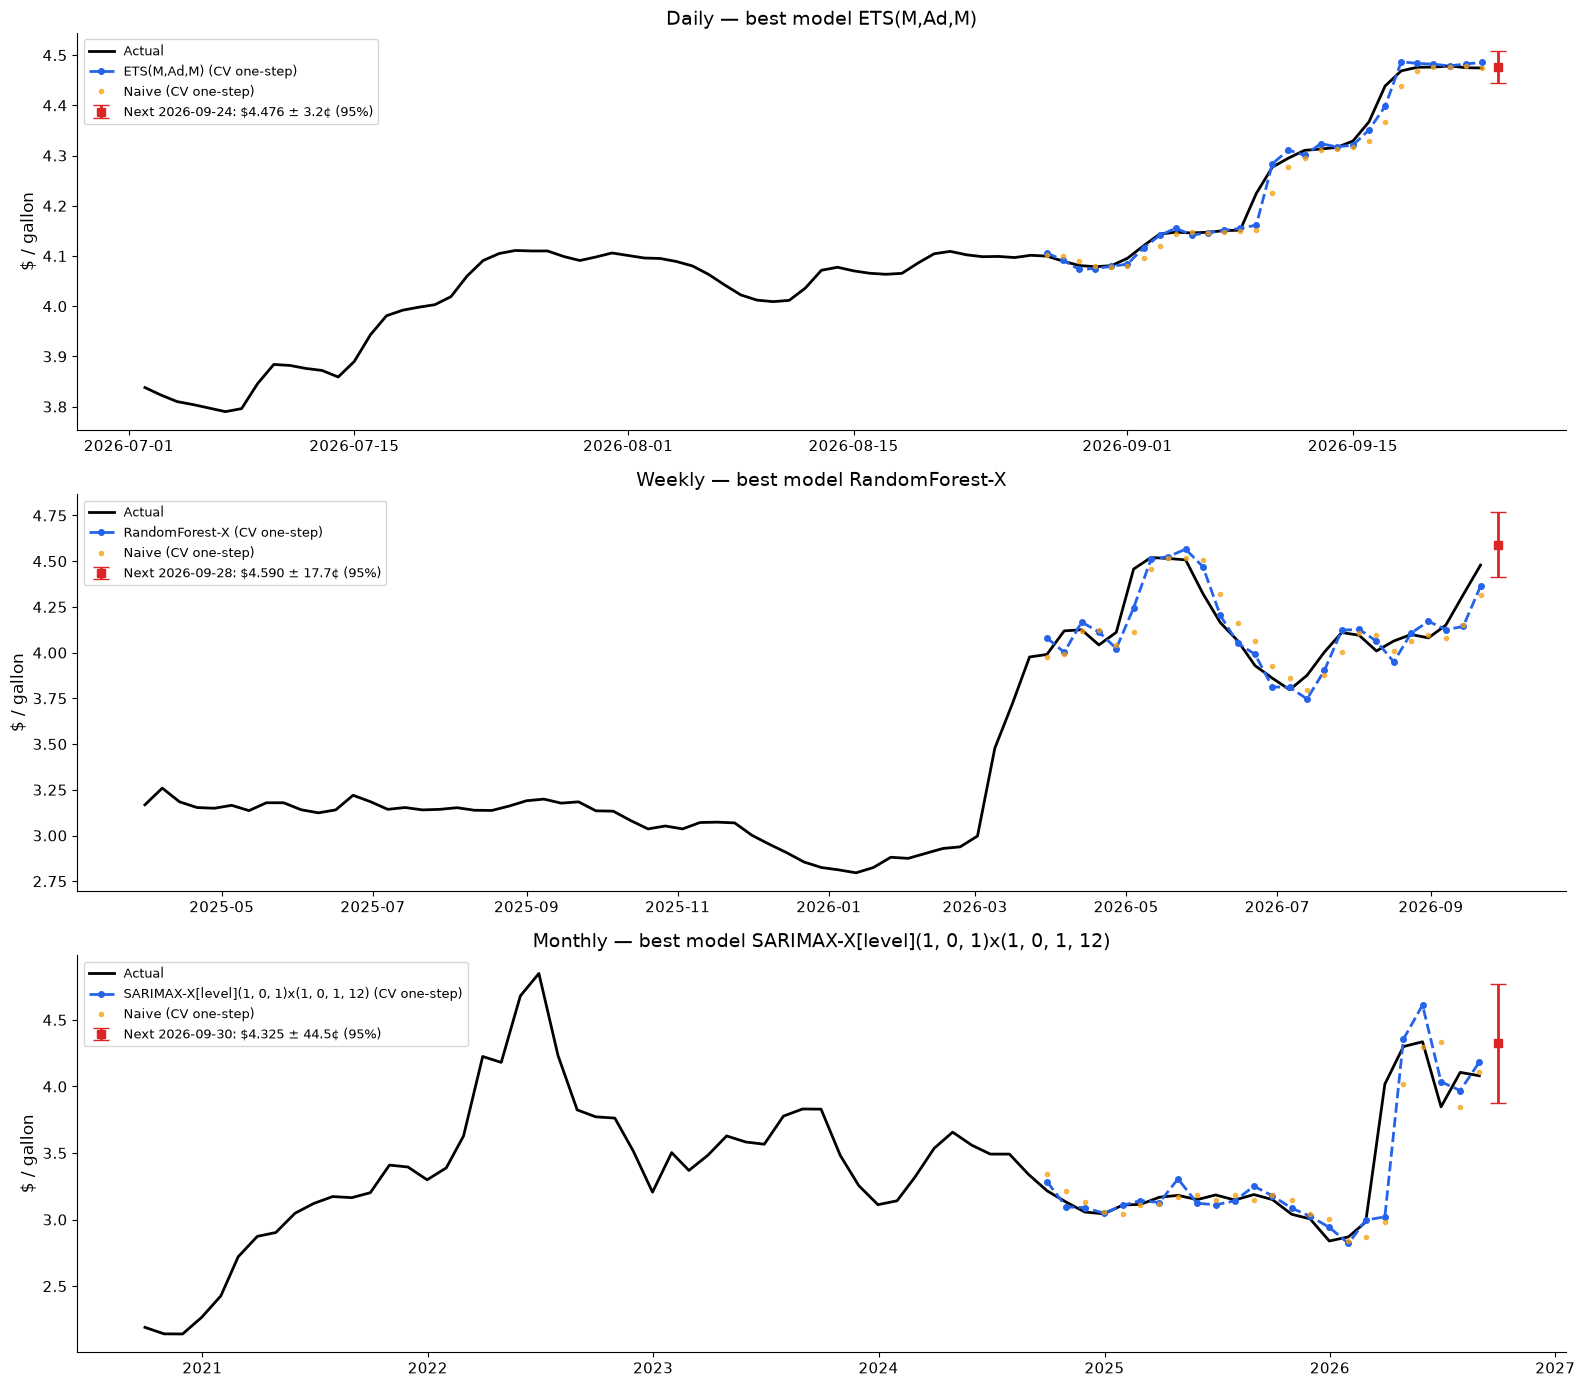

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
for ax, (k, t) in zip(axes, T.items(), strict=False):
    best = t["ranking"].iloc[0]["Model"]
    ts = t["ts"]
    window = ts.iloc[-(CFG[k]["n_folds"] * 3) :]
    ax.plot(window.index, window.values, color="black", label="Actual")
    ax.plot(
        t["cv_pred"][best].index,
        t["cv_pred"][best].values,
        "o--",
        color="#2563eb",
        markersize=4,
        label=f"{best} (CV one-step)",
    )
    ax.plot(
        t["cv_pred"]["Naive"].index,
        t["cv_pred"]["Naive"].values,
        ".",
        color="#f59e0b",
        alpha=0.7,
        label="Naive (CV one-step)",
    )
    fc, sd = t["forecasts"][best], np.std(t["cv_err"][best], ddof=1)
    ax.errorbar(
        [t["next_date"]],
        [fc],
        yerr=[[1.96 * sd], [1.96 * sd]],
        fmt="s",
        color="#dc2626",
        capsize=6,
        label=f'Next {t["next_date"]:%Y-%m-%d}: ${fc:.3f} ± {1.96 * sd * 100:.1f}¢ (95%)',
    )
    ax.set_title(f"{k.capitalize()} — best model {best}")
    ax.set_ylabel("$ / gallon")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4.6 Export Forecast Data

In [31]:
for k, t in T.items():
    t["ranking"].to_csv(OUT / f"01_aaa_gas_{k}_ranking_{AS_OF:%Y%m%d}.csv")
summary.to_csv(OUT / f"01_aaa_gas_summary_{AS_OF:%Y%m%d}.csv", index=False)
print(f"Saved rankings and summary to {OUT.resolve()}")

Saved rankings and summary to /Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/data/outputs


---
# Part 5: Critique & Next Steps

## Strengths of the Approach

| Strength | Detail |
|----------|--------|
| **Target = resolution source** | Kalshi's own `expiration_value` is the exact AAA number each contract settled on |
| **Validated proxy for history** | EIA weekly is bridged to AAA with measured bias and change correlation, not assumed |
| **Honest driver selection** | Lead-lag on changes + Granger + a placebo + out-of-sample with/without comparison |
| **No look-ahead** | Drivers lagged one calendar day, then one period on the target grid |
| **Automatic stationarity** | `d`, `D` and the exog mode (ECM / changes / levels) come from tests, identical in every notebook |
| **Same tournament as the original** | 14 model types across 4 families, each frequency picks its own winner |
| **Random-walk benchmark** | Every model is judged by skill vs Naive — the only bar that matters for prices |

## Limitations

| Limitation | Impact | Potential Mitigation |
|------------|--------|---------------------|
| **Daily history is short** (~6 months) | Daily models and daily CV are noisy | Record AAA daily going forward; look for a paid AAA/OPIS history |
| **Monthly model is stale** | It forecasts Sept 30 from Aug 31 while the market already sees late-September prices | Use the daily nowcast in Part 6 for monthly contracts |
| **Normal error distribution** | Tails (hurricanes, refinery outages) are fatter than normal | Student-t or empirical quantiles; widen σ in hurricane season |
| **No backtest vs historical Kalshi prices** | Edge in Part 6 is a live signal, not a proven P&L | Pull Kalshi candlesticks and replay: model probability vs price at bet time |
| **Missing fundamentals** | Inventories, refinery utilization (EIA weekly) not included | Add EIA API (needs free key) |
| **Weekly bet timing** | Models forecast a full week ahead; betting later in the week uses fresher wholesale data (lag k = 0) | A daily model conditioned on the latest wholesale close |

---
# Part 6: Kalshi Translation — Forecast → Probability → Edge

For each open event on Kalshi:
1. **Model probability:** best model of the matching frequency, X ~ N(forecast + mean CV error, σ of CV errors).
2. **Daily nowcast (cross-check):** start from the latest AAA daily value, add the empirical distribution of
   h-day changes (h = days until the contract date). This uses the freshest information, which matters most for
   weekly/monthly contracts late in the period.
3. **Market probability:** mid-price of the Yes contract.
4. **Edge after fees:** Kalshi fee ≈ 0.07 × P × (1 − P) per contract (rounded up per order).

A trade is flagged only when **both** the model and the nowcast agree on the side and the edge clears 3¢.

In [32]:
def kalshi_ladder(series_ticker):
    rows = []
    for m in kalshi_get("/markets", series_ticker=series_ticker, status="open"):

        def num(f, m=m):
            v = m.get(f)
            return float(v) if v not in (None, "") else np.nan

        rows.append(
            {
                "ticker": m["ticker"],
                "event_date": pd.to_datetime(m["event_ticker"].split("-")[1][:7], format="%y%b%d"),
                "strike": float(m.get("floor_strike") or m["ticker"].split("-")[-1]),
                "yes_bid": num("yes_bid_dollars"),
                "yes_ask": num("yes_ask_dollars"),
                "no_bid": num("no_bid_dollars"),
                "no_ask": num("no_ask_dollars"),
                "volume": num("volume_fp"),
                "open_interest": num("open_interest_fp"),
            }
        )
    df = pd.DataFrame(rows).sort_values(["event_date", "strike"]).reset_index(drop=True)
    df.loc[df["yes_ask"] <= 0, "yes_ask"] = np.nan  # 0 = no offer
    df["no_ask"] = 1 - df["yes_bid"]  # one order book: buying NO = selling YES at the bid
    df["mid"] = (df["yes_bid"] + df["yes_ask"].fillna(1)) / 2
    return df


def fee(p):
    return 0.07 * p * (1 - p)


snap_dir = Path("../data/kalshi_snapshots")
snap_dir.mkdir(parents=True, exist_ok=True)
stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
last_daily, last_daily_date = y_d.iloc[-1], y_d.index[-1]
edge_tables = {}

for k, t in T.items():
    ladder = kalshi_ladder(CFG[k]["series"])
    ladder.to_csv(snap_dir / f'{CFG[k]["series"]}_{stamp}.csv', index=False)
    best = t["ranking"].iloc[0]["Model"]
    errs = t["cv_err"][best]
    mu_model = t["forecasts"][best] + errs.mean()
    sd_model = errs.std(ddof=1)
    rows = []
    for ev_date, g in ladder.groupby("event_date"):
        h = (ev_date - last_daily_date).days
        chg = y_d.diff(h).dropna() if h > 0 else pd.Series([0.0])
        sd_now = max(chg.std(ddof=1), 0.002) if h > 0 else 0.002
        model_ok = ev_date == t["next_date"]
        g = g.copy()
        g["p_model"] = 1 - norm.cdf(g["strike"], mu_model, sd_model) if model_ok else np.nan
        g["p_nowcast"] = 1 - norm.cdf(g["strike"], last_daily, sd_now)
        g["edge_yes_model"] = g["p_model"] - g["yes_ask"] - fee(g["yes_ask"])
        g["edge_no_model"] = (1 - g["p_model"]) - g["no_ask"] - fee(g["no_ask"])
        g["edge_yes_now"] = g["p_nowcast"] - g["yes_ask"] - fee(g["yes_ask"])
        g["edge_no_now"] = (1 - g["p_nowcast"]) - g["no_ask"] - fee(g["no_ask"])
        g["signal"] = np.select(
            [
                (g["edge_yes_model"] > 0.03) & (g["edge_yes_now"] > 0.03),
                (g["edge_no_model"] > 0.03) & (g["edge_no_now"] > 0.03),
            ],
            ["BUY YES", "BUY NO"],
            "",
        )
        g["h_days"] = h
        rows.append(g)
    et = pd.concat(rows)
    edge_tables[k] = et
    print(
        f'\n{"=" * 100}\n{k.upper()} {CFG[k]["series"]} — best model {best}: '
        f'μ=${mu_model:.4f}, σ={sd_model*100:.2f}¢ for {t["next_date"]:%Y-%m-%d} | '
        f'nowcast from AAA {last_daily_date:%m-%d} = ${last_daily:.4f}\n{"=" * 100}'
    )
    for ev_date, g in et.groupby("event_date"):
        center = t["forecasts"][best] if ev_date == t["next_date"] else last_daily
        near = g[(g["strike"] - center).abs() <= 0.10]
        cols = [
            "strike",
            "yes_bid",
            "yes_ask",
            "no_ask",
            "mid",
            "p_model",
            "p_nowcast",
            "edge_yes_model",
            "edge_no_model",
            "edge_yes_now",
            "edge_no_now",
            "signal",
            "volume",
        ]
        print(
            f'\nEvent {ev_date:%Y-%m-%d} (h={g["h_days"].iloc[0]} days from last AAA daily)'
            + ("" if ev_date == t["next_date"] else "  [model horizon ≠ event date → nowcast only]")
        )
        print(near[cols].round(3).to_string(index=False))


DAILY KXAAAGASD — best model ETS(M,Ad,M): μ=$4.4783, σ=1.64¢ for 2026-09-24 | nowcast from AAA 09-23 = $4.4744

Event 2026-09-24 (h=1 days from last AAA daily)
 strike  yes_bid  yes_ask  no_ask   mid  p_model  p_nowcast  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now  signal   volume
  4.435     0.99     1.00    0.01 0.995    0.996      0.962          -0.004         -0.007        -0.038        0.027         18109.67
  4.440     0.99     1.00    0.01 0.995    0.990      0.940          -0.010         -0.001        -0.060        0.050          3415.51
  4.445     0.99     1.00    0.01 0.995    0.979      0.908          -0.021          0.010        -0.092        0.082          2184.00
  4.450     0.99     1.00    0.01 0.995    0.958      0.865          -0.042          0.031        -0.135        0.125  BUY NO  3210.06
  4.455     0.99     1.00    0.01 0.995    0.923      0.809          -0.077          0.066        -0.191        0.180  BUY NO  3388.46
  4.460     0.99     1.00    


WEEKLY KXAAAGASW — best model RandomForest-X: μ=$4.6061, σ=9.04¢ for 2026-09-28 | nowcast from AAA 09-23 = $4.4744

Event 2026-09-28 (h=5 days from last AAA daily)
 strike  yes_bid  yes_ask  no_ask   mid  p_model  p_nowcast  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now  signal   volume
   4.50     0.17     0.18    0.83 0.175    0.880      0.386           0.689         -0.719         0.196       -0.226 BUY YES  6819.11
   4.52     0.04     0.05    0.96 0.045    0.829      0.303           0.776         -0.792         0.250       -0.266 BUY YES  9322.80
   4.54     0.02     0.03    0.98 0.025    0.768      0.229           0.735         -0.749         0.197       -0.210 BUY YES  8224.90
   4.56     0.01     0.03    0.99 0.020    0.695      0.166           0.663         -0.686         0.134       -0.157 BUY YES 21625.35
   4.58     0.00     0.02    1.00 0.010    0.613      0.116           0.592         -0.613         0.095       -0.116 BUY YES 11600.65
   4.60     0.00     0.02

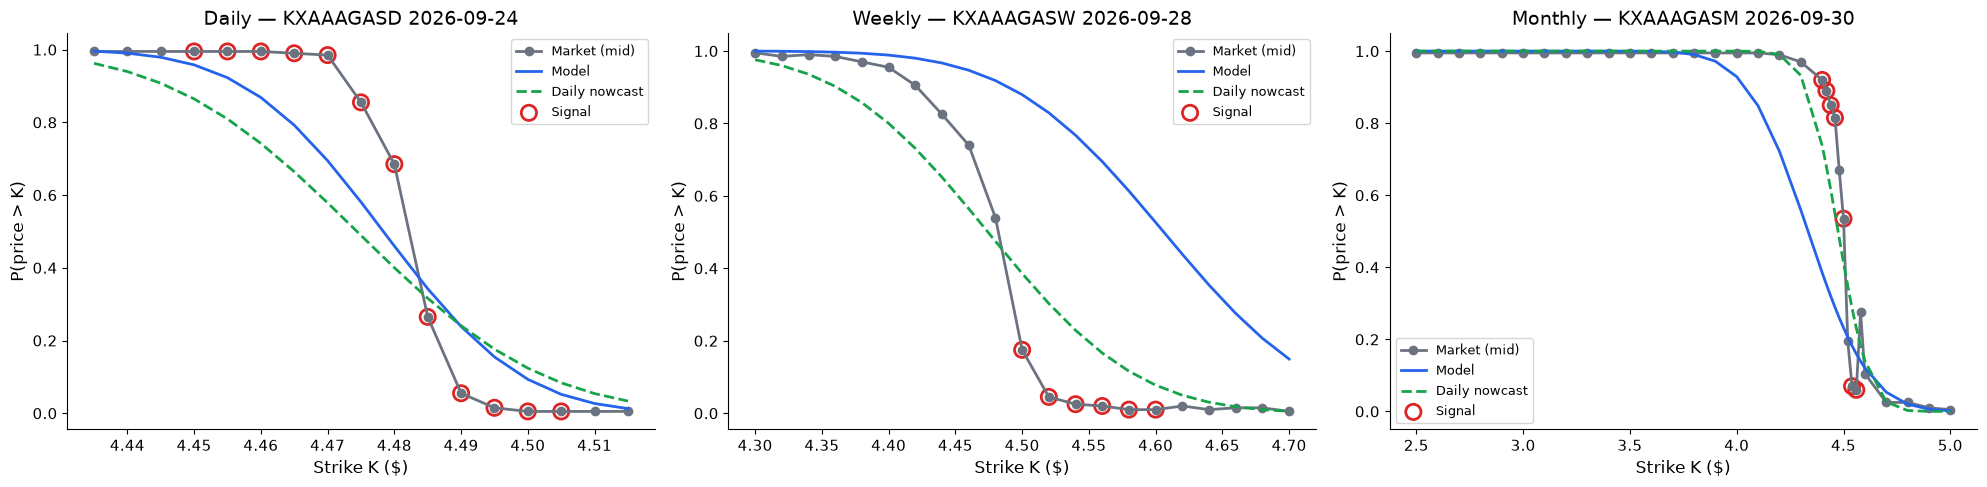

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (k, et) in zip(axes, edge_tables.items(), strict=False):
    ev = (
        T[k]["next_date"]
        if (et["event_date"] == T[k]["next_date"]).any()
        else et["event_date"].min()
    )
    g = et[et["event_date"] == ev]
    ax.plot(g["strike"], g["mid"], "o-", color="#6b7280", label="Market (mid)")
    if g["p_model"].notna().any():
        ax.plot(g["strike"], g["p_model"], "-", color="#2563eb", label="Model")
    ax.plot(g["strike"], g["p_nowcast"], "--", color="#16a34a", label="Daily nowcast")
    sig = g[g["signal"] != ""]
    ax.scatter(
        sig["strike"],
        sig["mid"],
        s=120,
        facecolors="none",
        edgecolors="#dc2626",
        linewidths=2,
        label="Signal",
    )
    ax.set_title(f'{k.capitalize()} — {CFG[k]["series"]} {ev:%Y-%m-%d}')
    ax.set_xlabel("Strike K ($)")
    ax.set_ylabel("P(price > K)")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Sanity check — how confident is the market compared with us?

The Yes mid-prices across strikes form the market's own distribution for X: the drop in P(X > K) between two
strikes is the probability that X lands between them. From it we get the **market-implied mean and σ**.

If the market's σ is much **smaller** than ours, the market is using information our models do not have
(fresher intraday pump prices, the latest wholesale moves). In that case a disagreement is far more likely to be
*our* missing information than an edge.

In [34]:
def implied_dist(g):
    g = g.sort_values("strike")
    p_above = np.clip(g["mid"].values, 0, 1)
    p_above = np.minimum.accumulate(p_above)  # enforce a monotone survival curve
    k = g["strike"].values
    edges = np.concatenate([[k[0] - (k[1] - k[0])], k, [k[-1] + (k[-1] - k[-2])]])
    surv = np.concatenate([[1.0], p_above, [0.0]])
    pmf = -np.diff(surv)
    centers = (edges[:-1] + edges[1:]) / 2
    pmf = np.clip(pmf, 0, None)
    pmf = pmf / pmf.sum()
    mu = (centers * pmf).sum()
    return mu, np.sqrt(((centers - mu) ** 2 * pmf).sum())


rows = []
for k, et in edge_tables.items():
    t = T[k]
    best = t["ranking"].iloc[0]["Model"]
    errs = t["cv_err"][best]
    for ev_date, g in et.groupby("event_date"):
        if len(g) < 3:
            continue
        mu_mkt, sd_mkt = implied_dist(g)
        h = g["h_days"].iloc[0]
        sd_now = y_d.diff(h).dropna().std(ddof=1) if h > 0 else np.nan
        on_model = ev_date == t["next_date"]
        rows.append(
            {
                "frequency": k,
                "event": ev_date.date(),
                "market_mu": mu_mkt,
                "market_sigma_¢": sd_mkt * 100,
                "model_mu": t["forecasts"][best] + errs.mean() if on_model else np.nan,
                "model_sigma_¢": errs.std(ddof=1) * 100 if on_model else np.nan,
                "nowcast_mu": last_daily,
                "nowcast_sigma_¢": sd_now * 100,
            }
        )
sharp = pd.DataFrame(rows)
sharp["model_vs_market_sigma"] = sharp["model_sigma_¢"] / sharp["market_sigma_¢"]
sharp.round(3)

,frequency,event,market_mu,market_sigma_¢,model_mu,model_sigma_¢,nowcast_mu,nowcast_sigma_¢,model_vs_market_sigma
0,daily,2026-09-24,4.482,0.706,4.478,1.639,4.474,2.215,2.321
1,weekly,2026-09-28,4.474,4.556,4.606,9.044,4.474,8.833,1.985
2,monthly,2026-09-30,4.486,17.259,4.334,22.723,4.474,11.661,1.317


In [35]:
signals = pd.concat(edge_tables.values())
signals = signals[signals["signal"] != ""]
print("=" * 80)
print(
    f"CANDIDATE SIGNALS (model and nowcast agree, edge > 3¢ after fees) — {pd.Timestamp.now():%Y-%m-%d %H:%M}"
)
print("=" * 80)
too_wide = sharp[sharp["model_vs_market_sigma"] > 2]
if not too_wide.empty:
    print("WARNING — our σ is more than 2x the market-implied σ for:")
    print(
        too_wide[["frequency", "event", "market_mu", "market_sigma_¢", "model_mu", "model_sigma_¢"]]
        .round(3)
        .to_string(index=False)
    )
    print(
        'The market knows more than our models for these events. Treat the "edges" below as information gaps,'
    )
    print("not as bets, until a backtest against historical Kalshi prices proves otherwise.\n")
if signals.empty:
    print("None. The market is consistent with our forecasts at the moment — no bet.")
else:
    print(
        signals[
            [
                "ticker",
                "strike",
                "yes_ask",
                "no_ask",
                "p_model",
                "p_nowcast",
                "edge_yes_model",
                "edge_no_model",
                "signal",
                "volume",
            ]
        ]
        .round(3)
        .to_string(index=False)
    )
print(
    "\nNot validated against historical Kalshi prices yet — treat as a research signal, not a bet sizing rule."
)

CANDIDATE SIGNALS (model and nowcast agree, edge > 3¢ after fees) — 2026-09-23 21:57
WARNING — our σ is more than 2x the market-implied σ for:
frequency      event  market_mu  market_sigma_¢  model_mu  model_sigma_¢
    daily 2026-09-24      4.482           0.706     4.478          1.639
The market knows more than our models for these events. Treat the "edges" below as information gaps,
not as bets, until a backtest against historical Kalshi prices proves otherwise.

                  ticker  strike  yes_ask  no_ask  p_model  p_nowcast  edge_yes_model  edge_no_model  signal   volume
KXAAAGASD-26SEP24-4.4500   4.450     1.00    0.01    0.958      0.865          -0.042          0.031  BUY NO  3210.06
KXAAAGASD-26SEP24-4.4550   4.455     1.00    0.01    0.923      0.809          -0.077          0.066  BUY NO  3388.46
KXAAAGASD-26SEP24-4.4600   4.460     1.00    0.01    0.869      0.742          -0.131          0.121  BUY NO  4144.68
KXAAAGASD-26SEP24-4.4650   4.465     1.00    0.02    0.7